### Single DRE

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

# setup
sigma_p = 1e-6 # narrow stdev
sigma_q = 1.0 # wide stdev
n = 10000 # Number of samples
rng = np.random.default_rng(0)

# p,q samples
xp = rng.normal(0.0, sigma_p, n)
xq = rng.normal(0.0, sigma_q, n)

In [ ]:
# gaussian pdf
def gauss(x, mu, sigma):
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2) / (np.sqrt(2 * np.pi) * sigma)

In [ ]:
# plot known densities
x = np.linspace(-5, 5, 1_000_000)
p = gauss(x, 0, sigma_p)
q = gauss(x, 0, sigma_q)

plt.plot(x, p, label='p(x)')
plt.plot(x, q, label='q(x)')
plt.xlim(-5, 5)
plt.xlabel('x')
plt.ylabel('density')
plt.legend()
plt.show()


In [ ]:
# --------------------------------------------------
# True log-ratio:
# log p(x)/q(x) = w_true * x^2 + b_true
# --------------------------------------------------
w_true = -1/(2*sigma_p**2) + 1/(2*sigma_q**2)
b_true = np.log(sigma_q / sigma_p)

In [ ]:
# --------------------------------------------------
# Single-ratio model:
# log r_theta(x) = -exp(theta) * x^2 + b_true
# (same quadratic form, 1 parameter on log scale)
# --------------------------------------------------
def log_r(x, theta):
    return -np.exp(theta) * x**2 + b_true

# Logistic loss from the paper:
# L = -E_p log(r/(1+r)) - E_q log(1/(1+r))
# Using log_r for numerical stability
def loss(theta):
    lp = log_r(xp, theta)
    lq = log_r(xq, theta)
    return np.mean(np.logaddexp(0, -lp)) + np.mean(np.logaddexp(0, lq))

In [ ]:
# --------------------------------------------------
# Fit theta by grid search (easy and stable in 1D)
# --------------------------------------------------
theta_grid = np.linspace(0, 35, 3000)
losses = np.array([loss(t) for t in theta_grid])

theta_hat = theta_grid[np.argmin(losses)]
w_hat = -np.exp(theta_hat)

theta_true = np.log(-w_true)

print("true theta =", theta_true)
print("est  theta =", theta_hat)
print("true w     =", w_true)
print("est  w     =", w_hat)
print("b_true     =", b_true)

In [ ]:
# --------------------------------------------------
# Plot true vs estimated ratio
# --------------------------------------------------
x = np.linspace(-5e-5, 5e-5, 5000)  # zoom near 0 so the ratio shape is visible

log_ratio_true = w_true * x**2 + b_true
log_ratio_hat  = w_hat  * x**2 + b_true

ratio_true = np.exp(np.clip(log_ratio_true, -745, 700))
ratio_hat  = np.exp(np.clip(log_ratio_hat,  -745, 700))

plt.figure(figsize=(6,4))
plt.plot(x, ratio_true, label='true ratio', color='black', linewidth=2)
plt.plot(x, ratio_hat, label='single DRE estimate', color='blue', linestyle='--', linewidth=2)
plt.xlabel('x')
plt.ylabel('p(x) / q(x)')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(theta_grid, losses, color='blue')
plt.axvline(theta_true, color='black', linestyle=':', label='true')
plt.axvline(theta_hat, color='red', linestyle=':', label='estimated')
plt.yscale('log')
plt.xlabel('theta')
plt.ylabel('logistic loss')
plt.legend()
plt.tight_layout()
plt.show()

### Logistic TRE

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1) Problem setup: peaked Gaussian p and broad Gaussian q
# ============================================================
sigma_p = 1e-6   # p(x) = N(0, sigma_p^2)
sigma_q = 1.0    # q(x) = N(0, sigma_q^2)
n = 10_000
rng = np.random.default_rng(0)

# Paired endpoint samples: x0 ~ p, xm ~ q
x0 = rng.normal(0.0, sigma_p, n)
xm = rng.normal(0.0, sigma_q, n)

# ============================================================
# 2) Choose waymarks
#    We'll use m bridges, so there are m+1 distributions:
#    p0 = p, p1, ..., pm = q
#
#    To make the intermediate problems sensible, we choose the
#    target std-devs geometrically between sigma_p and sigma_q:
#       sigma_0, sigma_1, ..., sigma_m
#
#    Then solve for alpha_k so that x_k has variance sigma_k^2.
# ============================================================
m = 4  # number of bridges; gives p0 -> p1 -> p2 -> p3 -> p4=q

sigmas = np.geomspace(sigma_p, sigma_q, m + 1)

# For interpolation
# x_k = sqrt(1 - alpha_k^2) * x0 + alpha_k * xm
# Since x0 ~ N(0, sigma_p^2), xm ~ N(0, sigma_q^2),
# the variance of x_k is:
#   Var(x_k) = (1-alpha_k^2)*sigma_p^2 + alpha_k^2*sigma_q^2
# Solve this for alpha_k so that Var(x_k) = sigmas[k]^2.
alphas = np.sqrt((sigmas**2 - sigma_p**2) / (sigma_q**2 - sigma_p**2))
alphas[0] = 0.0
alphas[-1] = 1.0

# Build the waymark samples x_k for k=0,...,m
waymarks = []
for a in alphas:
    xk = np.sqrt(1 - a**2) * x0 + a * xm
    waymarks.append(xk)

# ============================================================
# 3) Ground-truth bridge coefficients
#
#    If p_k = N(0, sigma_k^2) and p_{k+1} = N(0, sigma_{k+1}^2),
#    then
#       log(p_k(x)/p_{k+1}(x)) = w_k^* x^2 + b_k^*
#
#    where
#       w_k^* = -1/(2 sigma_k^2) + 1/(2 sigma_{k+1}^2)
#       b_k^* = log(sigma_{k+1} / sigma_k)
#
#    We fix b_k to its ground-truth value, following the paper.
# ============================================================
w_true = []
b_true = []

for k in range(m):
    s0 = sigmas[k]
    s1 = sigmas[k + 1]
    wk = -1 / (2 * s0**2) + 1 / (2 * s1**2)
    bk = np.log(s1 / s0)
    w_true.append(wk)
    b_true.append(bk)

w_true = np.array(w_true)
b_true = np.array(b_true)

# ============================================================
# 4) Logistic loss for a single bridge
#
#    Model:
#       log r_k(x; theta_k) = -exp(theta_k) * x^2 + b_k
#
#    This is the same quadratic form as in the paper, with the
#    sign chosen correctly for this Gaussian example.
# ============================================================
def bridge_log_ratio(x, theta, b):
    return -np.exp(theta) * x**2 + b

def bridge_loss(theta, x_left, x_right, b):
    # Logistic DRE loss:
    #   -E_{x~p_k} log( r/(1+r) ) - E_{x~p_{k+1}} log( 1/(1+r) )
    #
    # Using log_r for numerical stability:
    #   log(1 + exp(-log_r)) = logaddexp(0, -log_r)
    #   log(1 + exp( log_r)) = logaddexp(0,  log_r)
    log_r_left = bridge_log_ratio(x_left, theta, b)
    log_r_right = bridge_log_ratio(x_right, theta, b)
    return np.mean(np.logaddexp(0, -log_r_left)) + np.mean(np.logaddexp(0, log_r_right))

# ============================================================
# 5) Fit each bridge separately by grid search
#
#    This keeps the 1D toy experiment very clean and stable.
# ============================================================
theta_hat = []
w_hat = []
bridge_losses = []
theta_grids = []

for k in range(m):
    x_left = waymarks[k]
    x_right = waymarks[k + 1]

    # True theta corresponding to w_k^* = -exp(theta_k^*)
    theta_true_k = np.log(-w_true[k])

    # Search in a window around the true value
    grid = np.linspace(theta_true_k - 6, theta_true_k + 6, 3000)
    losses = np.array([bridge_loss(t, x_left, x_right, b_true[k]) for t in grid])

    th = grid[np.argmin(losses)]
    wk = -np.exp(th)

    theta_grids.append(grid)
    bridge_losses.append(losses)
    theta_hat.append(th)
    w_hat.append(wk)

theta_hat = np.array(theta_hat)
w_hat = np.array(w_hat)

# ============================================================
# 6) Build the final TRE estimate:
#       log r_TRE(x) = sum_k log r_k(x)
# ============================================================
def log_ratio_true(x):
    # True single ratio log p(x)/q(x)
    return (-1/(2*sigma_p**2) + 1/(2*sigma_q**2)) * x**2 + np.log(sigma_q / sigma_p)

def log_ratio_tre(x):
    total = np.zeros_like(x)
    for k in range(m):
        total += w_hat[k] * x**2 + b_true[k]
    return total

# ============================================================
# 7) Print bridge parameters
# ============================================================
print("Bridge-wise fits:")
for k in range(m):
    print(f"bridge {k}: sigma_k={sigmas[k]:.3e}, sigma_k+1={sigmas[k+1]:.3e}")
    print(f"  true theta = {np.log(-w_true[k]):.6f}")
    print(f"  est  theta = {theta_hat[k]:.6f}")
    print(f"  true w     = {w_true[k]:.6e}")
    print(f"  est  w     = {w_hat[k]:.6e}")
    print(f"  b_true     = {b_true[k]:.6f}")
    print()

# ============================================================
# 8) Plot final TRE ratio vs true ratio
#    Zoom near 0, because the true ratio is extremely peaked.
# ============================================================
x_plot = np.linspace(-5e-5, 5e-5, 5000)

log_r_true = log_ratio_true(x_plot)
log_r_tre = log_ratio_tre(x_plot)

r_true = np.exp(np.clip(log_r_true, -745, 700))
r_tre = np.exp(np.clip(log_r_tre, -745, 700))

plt.figure(figsize=(7, 4))
plt.plot(x_plot, r_true, color='black', linewidth=2, label='true ratio')
plt.plot(x_plot, r_tre, color='red', linestyle='--', linewidth=2, label='TRE estimate')
plt.xlabel('x')
plt.ylabel('p(x) / q(x)')
plt.title('1D peaked ratio: logistic TRE')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 9) Single-ratio logistic DRE loss curve + Figure 1a-style plot
# ============================================================

# True single-ratio parameters:
#   log r(x) = w_single_true * x^2 + b_single_true
w_single_true = -1/(2*sigma_p**2) + 1/(2*sigma_q**2)
b_single_true = np.log(sigma_q / sigma_p)

# Single-ratio model:
#   log r_theta(x) = -exp(theta) * x^2 + b_single_true
def single_log_ratio(x, theta):
    return -np.exp(theta) * x**2 + b_single_true

# Logistic loss for the single DRE case
def single_loss(theta):
    log_r_p = single_log_ratio(x0, theta)   # samples from p
    log_r_q = single_log_ratio(xm, theta)   # samples from q
    return np.mean(np.logaddexp(0, -log_r_p)) + np.mean(np.logaddexp(0, log_r_q))

# True theta for the single-ratio problem
theta_true = np.log(-w_single_true)

# Empirical TRE-equivalent theta:
# log r_TRE(x) = (sum_k w_hat[k]) x^2 + sum_k b_k
# so the total quadratic coefficient is sum_k w_hat[k]
theta_tre = np.log(-np.sum(w_hat))

# Build a theta grid for the single-ratio loss curve
theta_grid = np.linspace(theta_true - 18, theta_true + 2, 3000)
losses = np.array([single_loss(t) for t in theta_grid])

# Single DRE empirical minimizer
theta_hat = theta_grid[np.argmin(losses)]

# ============================================================
# 10) Plot like the paper figure
# ============================================================
plt.style.use('ggplot')

fig, ax = plt.subplots(figsize=(9, 4.5))

ax.plot(theta_grid, losses, color='blue', lw=2, label=r'$\mathcal{L}^n(\theta)$')
ax.axvline(theta_hat,  color='blue',  ls='--', lw=2, label=r'$\hat{\theta}$')
ax.axvline(theta_true, color='black', ls='--', lw=4, label=r'$\theta^*$')
ax.axvline(theta_tre,  color='red',   ls='--', lw=2, label=r'$\theta_{TRE}$')

ax.set_xlabel(r'$\theta$', fontsize=28)
ax.set_ylabel('logistic loss', fontsize=26)
ax.tick_params(labelsize=18)
ax.legend(loc='upper left', fontsize=24, framealpha=0.9)

plt.yscale('log')
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1) Problem setup: peaked Gaussian p and broad Gaussian q
# ============================================================
sigma_p = 1e-6   # p(x) = N(0, sigma_p^2)
sigma_q = 1.0    # q(x) = N(0, sigma_q^2)
n = 10_000
rng = np.random.default_rng(0)

# Paired endpoint samples: x0 ~ p, xm ~ q
x0 = rng.normal(0.0, sigma_p, n)
xm = rng.normal(0.0, sigma_q, n)

# ============================================================
# 2) Choose waymarks
#    p0 = p, p1, ..., pm = q
# ============================================================
m = 4  # number of bridges

sigmas = np.geomspace(sigma_p, sigma_q, m + 1)

# x_k = sqrt(1 - alpha_k^2) * x0 + alpha_k * xm
alphas = np.sqrt((sigmas**2 - sigma_p**2) / (sigma_q**2 - sigma_p**2))
alphas[0] = 0.0
alphas[-1] = 1.0

waymarks = []
for a in alphas:
    xk = np.sqrt(1 - a**2) * x0 + a * xm
    waymarks.append(xk)

# ============================================================
# 3) Ground-truth bridge coefficients
#
#    For p_k = N(0, sigma_k^2), p_{k+1} = N(0, sigma_{k+1}^2):
#       log(p_k(x)/p_{k+1}(x)) = w_k^* x^2 + b_k^*
#
#    Since the DRE operator is
#       A_t[p_{t+1}](x) = (∫ p_{t+1}) p_t(x),
#    and the Gaussian densities are normalized, ∫ p_{t+1} = 1,
#    so the target ratio is simply:
#       r_t(x) = p_t(x) / p_{t+1}(x)
# ============================================================
w_true = []
b_true = []

for k in range(m):
    s0 = sigmas[k]
    s1 = sigmas[k + 1]
    wk = -1 / (2 * s0**2) + 1 / (2 * s1**2)
    bk = np.log(s1 / s0)
    w_true.append(wk)
    b_true.append(bk)

w_true = np.array(w_true)
b_true = np.array(b_true)

# ============================================================
# 4) True bridge ratio and model theta_q
#
#    We parametrize theta_q(x,t) using the same quadratic form:
#       log theta_q(x,t) = -exp(theta_t) * x^2 + b_t
#
#    So theta_q(x,t) itself is
#       theta_q(x,t) = exp( -exp(theta_t) * x^2 + b_t )
#
#    The true target bridge ratio is
#       r_t(x) = exp( w_true[t] * x^2 + b_true[t] )
# ============================================================
def true_bridge_ratio(x, t):
    return np.exp(np.clip(w_true[t] * x**2 + b_true[t], -745, 700))

def theta_q(x, theta, b):
    log_q = -np.exp(theta) * x**2 + b
    return np.exp(np.clip(log_q, -745, 700))

# ============================================================
# 5) Bregman divergence for squared loss
#
#    Choose F(u) = 1/2 * u^2
#    Then:
#       B_F(u, v) = F(u) - F(v) - F'(v)(u - v)
#                  = 1/2 * (u - v)^2
#
#    Expected objective at bridge t:
#       D_F(r_t, theta_q(. , t))
#       = E_{x ~ p_{t+1}} [ 1/2 * (r_t(x) - theta_q(x,t))^2 ]
# ============================================================
def F(u):
    return 0.5 * u**2

def dF(u):
    return u

def B_F(u, v):
    return F(u) - F(v) - dF(v) * (u - v)

def expected_bregman_loss(theta, x_next, t):
    # x_next are samples from p_{t+1}
    r_t = true_bridge_ratio(x_next, t)
    q_t = theta_q(x_next, theta, b_true[t])
    return np.mean(B_F(r_t, q_t))

# ============================================================
# 6) Fit each bridge by minimizing the expected Bregman loss
#    using Monte Carlo samples from p_{t+1}
# ============================================================
theta_hat = []
w_hat = []
bridge_losses = []
theta_grids = []

for t in range(m):
    x_next = waymarks[t + 1]   # expectation under p_{t+1}

    # True theta satisfies w_true[t] = -exp(theta_true_t)
    theta_true_t = np.log(-w_true[t])

    # Search in a window around the true value
    grid = np.linspace(theta_true_t - 6, theta_true_t + 6, 3000)
    losses = np.array([expected_bregman_loss(th, x_next, t) for th in grid])

    th_hat = grid[np.argmin(losses)]
    wk_hat = -np.exp(th_hat)

    theta_grids.append(grid)
    bridge_losses.append(losses)
    theta_hat.append(th_hat)
    w_hat.append(wk_hat)

theta_hat = np.array(theta_hat)
w_hat = np.array(w_hat)

# ============================================================
# 7) Build the final TRE estimate:
#       r_TRE(x) = Π_t theta_q(x,t)
#    so in log-space:
#       log r_TRE(x) = Σ_t [ w_hat[t] x^2 + b_true[t] ]
# ============================================================
def log_ratio_true(x):
    return (-1/(2*sigma_p**2) + 1/(2*sigma_q**2)) * x**2 + np.log(sigma_q / sigma_p)

def log_ratio_tre(x):
    total = np.zeros_like(x)
    for t in range(m):
        total += w_hat[t] * x**2 + b_true[t]
    return total

# ============================================================
# 8) Print bridge parameters
# ============================================================
print("Bridge-wise fits (Expected Bregman divergence, squared loss):")
for t in range(m):
    print(f"bridge {t}: sigma_t={sigmas[t]:.3e}, sigma_t+1={sigmas[t+1]:.3e}")
    print(f"  true theta = {np.log(-w_true[t]):.6f}")
    print(f"  est  theta = {theta_hat[t]:.6f}")
    print(f"  true w     = {w_true[t]:.6e}")
    print(f"  est  w     = {w_hat[t]:.6e}")
    print(f"  b_true     = {b_true[t]:.6f}")
    print()

# ============================================================
# 9) Plot final TRE ratio vs true ratio
# ============================================================
x_plot = np.linspace(-5e-5, 5e-5, 5000)

log_r_true = log_ratio_true(x_plot)
log_r_tre = log_ratio_tre(x_plot)

r_true = np.exp(np.clip(log_r_true, -745, 700))
r_tre = np.exp(np.clip(log_r_tre, -745, 700))

plt.figure(figsize=(7, 4))
plt.plot(x_plot, r_true, color='black', linewidth=2, label='true ratio')
plt.plot(x_plot, r_tre, color='red', linestyle='--', linewidth=2, label='TRE estimate')
plt.xlabel('x')
plt.ylabel('p(x) / q(x)')
plt.title('1D peaked ratio: TRE with expected Bregman divergence')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

# ============================================================
# Configuration
# ============================================================
sigma_p = 1e-6
sigma_q = 1.0
n = 10_000
m = 4
n_tries = 5

# ============================================================
# Ground-truth single-ratio parameters
# log(p(x)/q(x)) = w_single_true * x^2 + b_single_true
# ============================================================
w_single_true = -1 / (2 * sigma_p**2) + 1 / (2 * sigma_q**2)
b_single_true = np.log(sigma_q / sigma_p)
theta_true = np.log(-w_single_true)

# ============================================================
# Waymark stds and ground-truth bridge parameters
# log(p_t / p_{t+1}) = w_true[t] * x^2 + b_true[t]
# ============================================================
sigmas = np.geomspace(sigma_p, sigma_q, m + 1)
alphas = np.sqrt((sigmas**2 - sigma_p**2) / (sigma_q**2 - sigma_p**2))
alphas[0], alphas[-1] = 0.0, 1.0

w_true = np.array([
    -1 / (2 * sigmas[t]**2) + 1 / (2 * sigmas[t + 1]**2)
    for t in range(m)
])
b_true = np.array([
    np.log(sigmas[t + 1] / sigmas[t])
    for t in range(m)
])

# ============================================================
# Helpers
# ============================================================
def exp_clip(z):
    return np.exp(np.clip(z, -745, 700))

def log_model(x, theta, b):
    # log r_theta(x) = -exp(theta) * x^2 + b
    return -np.exp(theta) * x**2 + b

def model_ratio(x, theta, b):
    return exp_clip(log_model(x, theta, b))

def true_ratio(x, w, b):
    return exp_clip(w * x**2 + b)

def fit_on_grid(loss_fn, theta_center, width, n_grid=3000):
    grid = np.linspace(theta_center - width, theta_center + width, n_grid)
    losses = np.array([loss_fn(th) for th in grid])
    theta_hat = grid[np.argmin(losses)]
    w_hat = -np.exp(theta_hat)
    return theta_hat, w_hat

def theta_metrics(theta_est, theta_ref):
    abs_err = abs(theta_est - theta_ref)
    rel_err = abs_err / abs(theta_ref)
    score = 100.0 * max(0.0, 1.0 - rel_err)   # accuracy-like score
    return abs_err, rel_err, score

# ============================================================
# One run
# ============================================================
def run_once(seed):
    rng = np.random.default_rng(seed)

    # Samples from p and q
    xp = rng.normal(0.0, sigma_p, n)
    xq = rng.normal(0.0, sigma_q, n)

    # Waymarks
    waymarks = [np.sqrt(1 - a**2) * xp + a * xq for a in alphas]

    # --------------------------------------------------------
    # 1) Single-ratio logistic baseline
    # --------------------------------------------------------
    def single_logistic_loss(theta):
        lp = log_model(xp, theta, b_single_true)
        lq = log_model(xq, theta, b_single_true)
        return np.mean(np.logaddexp(0, -lp)) + np.mean(np.logaddexp(0, lq))

    theta_single, _ = fit_on_grid(
        single_logistic_loss,
        theta_center=theta_true,
        width=18.0
    )

    # --------------------------------------------------------
    # 2) Logistic TRE
    # --------------------------------------------------------
    def logistic_bridge_loss(theta, x_left, x_right, b):
        log_r_left = log_model(x_left, theta, b)
        log_r_right = log_model(x_right, theta, b)
        return np.mean(np.logaddexp(0, -log_r_left)) + np.mean(np.logaddexp(0, log_r_right))

    w_logistic_bridges = []
    theta_logistic_bridges = []

    for t in range(m):
        theta_t, w_t = fit_on_grid(
            lambda th, t=t: logistic_bridge_loss(th, waymarks[t], waymarks[t + 1], b_true[t]),
            theta_center=np.log(-w_true[t]),
            width=6.0
        )
        theta_logistic_bridges.append(theta_t)
        w_logistic_bridges.append(w_t)

    theta_logistic_bridges = np.array(theta_logistic_bridges)
    w_logistic_bridges = np.array(w_logistic_bridges)
    theta_logistic_tre = np.log(-np.sum(w_logistic_bridges))

    # --------------------------------------------------------
    # 3) BLOD TRE (Bregman / squared loss)
    # --------------------------------------------------------
    def bregman_bridge_loss(theta, t):
        x_next = waymarks[t + 1]   # expectation under p_{t+1}
        r_t = true_ratio(x_next, w_true[t], b_true[t])
        q_t = model_ratio(x_next, theta, b_true[t])
        return np.mean(0.5 * (r_t - q_t) ** 2)

    w_bregman_bridges = []
    theta_bregman_bridges = []

    for t in range(m):
        theta_t, w_t = fit_on_grid(
            lambda th, t=t: bregman_bridge_loss(th, t),
            theta_center=np.log(-w_true[t]),
            width=6.0
        )
        theta_bregman_bridges.append(theta_t)
        w_bregman_bridges.append(w_t)

    theta_bregman_bridges = np.array(theta_bregman_bridges)
    w_bregman_bridges = np.array(w_bregman_bridges)
    theta_bregman_tre = np.log(-np.sum(w_bregman_bridges))

    return {
        "Single (logistic)": theta_single,
        "Logistic TRE": theta_logistic_tre,
        "BLOD TRE": theta_bregman_tre,
        "Logistic TRE bridges": theta_logistic_bridges,
        "BLOD TRE bridges": theta_bregman_bridges,
    }

# ============================================================
# Run over multiple tries
# ============================================================
all_results = []
for seed in range(n_tries):
    all_results.append(run_once(seed))

# ============================================================
# Aggregate results
# ============================================================
methods = ["Single (logistic)", "Logistic TRE", "BLOD TRE"]

print(f"theta_true = {theta_true:.6f}\n")
print(f"Averaged over {n_tries} tries:\n")

for method in methods:
    thetas = np.array([res[method] for res in all_results])

    abs_errs = []
    rel_errs = []
    scores = []
    for theta_est in thetas:
        abs_err, rel_err, score = theta_metrics(theta_est, theta_true)
        abs_errs.append(abs_err)
        rel_errs.append(rel_err)
        scores.append(score)

    abs_errs = np.array(abs_errs)
    rel_errs = np.array(rel_errs)
    scores = np.array(scores)

    print(f"{method:18s}")
    print(f"  theta      = {thetas.mean():.6f} ± {thetas.std(ddof=1):.6f}")
    print(f"  |error|    = {abs_errs.mean():.6f} ± {abs_errs.std(ddof=1):.6f}")
    print(f"  rel_error  = {100*rel_errs.mean():.4f}% ± {100*rel_errs.std(ddof=1):.4f}%")
    print(f"  theta_score= {scores.mean():.2f}% ± {scores.std(ddof=1):.2f}%")
    print()

# Optional: average bridge-wise thetas too
logistic_bridge_thetas = np.array([res["Logistic TRE bridges"] for res in all_results])
bregman_bridge_thetas = np.array([res["BLOD TRE bridges"] for res in all_results])

print("Average bridge-wise thetas:")
print("  Logistic TRE:", np.round(logistic_bridge_thetas.mean(axis=0), 6))
print("  BLOD TRE:    ", np.round(bregman_bridge_thetas.mean(axis=0), 6))

In [ ]:
import numpy as np

# -----------------------------
# settings
# -----------------------------
sigma_p, sigma_q = 1e-6, 1.0
n, m, n_tries = 10_000, 4, 5

# -----------------------------
# true single-ratio parameters
# log(p/q) = w* x^2 + b*
# -----------------------------
w_star = 1/2 * ((1/sigma_q**2) - (1/sigma_p**2))
b_star = np.log(sigma_q / sigma_p)
theta_star = np.log(-w_star)

# -----------------------------
# waymark setup
# -----------------------------
sigmas = np.geomspace(sigma_p, sigma_q, m + 1)
alphas = np.sqrt((sigmas**2 - sigma_p**2) / (sigma_q**2 - sigma_p**2))
alphas[[0, -1]] = 0.0, 1.0

w_bridge_star = -1 / (2 * sigmas[:-1]**2) + 1 / (2 * sigmas[1:]**2)
b_bridge_star = np.log(sigmas[1:] / sigmas[:-1])

# -----------------------------
# helpers
# -----------------------------

def log_ratio_model(x, theta, b):
    """
    Log density-ratio *model* for a Gaussian-to-Gaussian ratio.

    THEORY
    ------
    For two zero-mean Gaussians:
        p(x) = N(0, σ_p^2)
        q(x) = N(0, σ_q^2)

    the true log density ratio has the form:
        log(p(x)/q(x)) = w x^2 + b

    where:
        w = -1/(2σ_p^2) + 1/(2σ_q^2)    (note: w < 0 if σ_p < σ_q)
        b = log(σ_q / σ_p)

    PARAMETERIZATION
    ----------------
    We *reparameterize* the quadratic coefficient as:
        w = -exp(theta)

    This guarantees:
        - w < 0 automatically
        - theta is unconstrained (theta ∈ ℝ)
        - numerical stability during optimization

    So the modeled log-ratio is:
        log r(x; θ, b) = -exp(θ) * x^2 + b

    INPUTS
    ------
    x     : scalar or array of samples
    theta : unconstrained curvature parameter
    b     : bias (normalization term)

    OUTPUT
    ------
    log r(x) evaluated at x
    """
    return -np.exp(theta) * x**2 + b


def ratio_from_log(log_r):
    """
    Convert log-ratio values into ratio values safely.

    NUMERICAL ISSUE
    ---------------
    r(x) = exp(log r(x)) can overflow / underflow:
      - exp(> ~700)  → inf
      - exp(< ~-745) → 0 (underflow to 0)

    SOLUTION
    --------
    We clip log-ratios to a safe floating-point range before exponentiating.

    This does NOT change the mathematical model —
    it only prevents numerical crashes.

    INPUT
    -----
    log_r : array or scalar of log-ratio values

    OUTPUT
    ------
    r(x) = exp(log_r), numerically stabilized
    """
    return np.exp(np.clip(log_r, -745, 700))


def ratio_model(x, theta, b):
    """
    Full **modeled density ratio** r(x; θ, b).

    This is just the composition:
        r(x) = exp(log r(x))

    where log r(x) is given by the quadratic model:
        log r(x) = -exp(theta) * x^2 + b

    INPUTS
    ------
    x     : samples
    theta : curvature parameter (unconstrained)
    b     : bias

    OUTPUT
    ------
    Modeled density ratio r(x)
    """
    return ratio_from_log(log_ratio_model(x, theta, b))


def ratio_true(x, w, b):
    """
    Ground-truth density ratio for Gaussian pairs.

    THEORY
    ------
    If we know the *true* parameters:
        w = -1/(2σ_p^2) + 1/(2σ_q^2)
        b = log(σ_q / σ_p)

    then the exact ratio is:
        r*(x) = exp(w x^2 + b)

    This function is used:
        - for diagnostics
        - for sanity checks
        - to compare learned vs true models

    INPUTS
    ------
    x : samples
    w : true quadratic coefficient (negative)
    b : true bias

    OUTPUT
    ------
    True density ratio r*(x)
    """
    return ratio_from_log(w * x**2 + b)


def fit_theta(loss_fn, center, width, n_grid=3000):
    """
    Brute-force 1D optimization over theta.

    PURPOSE
    -------
    Since the model:
        w = -exp(theta)

    is *nonlinear*, we optimize in theta-space.
    This helper does a simple grid search.

    PROCEDURE
    ---------
    1. Build a grid:
           theta ∈ [center - width, center + width]
    2. Evaluate the loss at each grid point
    3. Select the minimizer

    This is:
        - slow but robust
        - useful for experiments & debugging
        - avoids gradient pathologies

    RETURNED VALUES
    ---------------
    theta_hat : best theta found
    w_hat     : corresponding quadratic coefficient
                (computed via w = -exp(theta))

    NOTE
    ----
    This mirrors the theory exactly:
        theta* = log(-w*)
    """
    grid = np.linspace(center - width, center + width, n_grid)

    # Evaluate loss(theta) for each candidate theta
    theta = grid[np.argmin([loss_fn(t) for t in grid])]

    # Return both theta and the implied quadratic coefficient
    return theta, -np.exp(theta)

def metrics(theta, theta_ref):
    err = abs(theta - theta_ref)
    rel = err / abs(theta_ref)
    score = 100 * max(0.0, 1 - rel)
    return err, rel, score

def summarize(name, values, theta_ref):
    values = np.array(values)
    errs, rels, scores = np.array([metrics(v, theta_ref) for v in values]).T
    print(f"{name:18s}")
    print(f"  theta       = {values.mean():.6f} ± {values.std(ddof=1):.6f}")
    print(f"  |error|     = {errs.mean():.6f} ± {errs.std(ddof=1):.6f}")
    print(f"  rel_error   = {100*rels.mean():.4f}% ± {100*rels.std(ddof=1):.4f}%")
    print(f"  theta_score = {scores.mean():.2f}% ± {scores.std(ddof=1):.2f}%")
    print()

# -----------------------------
# one experiment
# -----------------------------
def run(seed):
    """
    Run a single experimental trial comparing:

      1) A single-shot density ratio fit (no waymarks)
      2) Logistic TRE with waymarks
      3) BLOD / Bregman TRE with waymarks

    All methods ultimately estimate the *same global quadratic curvature*
    corresponding to:
        log(p(x)/q(x)) = w* x^2 + b*

    The difference is HOW that curvature is estimated.
    """

    # Random number generator for reproducibility
    rng = np.random.default_rng(seed)

    # ---------------------------------------------------------
    # Sample from endpoint distributions
    # ---------------------------------------------------------
    # p(x) = N(0, sigma_p^2)
    # q(x) = N(0, sigma_q^2)
    xp = rng.normal(0.0, sigma_p, n)
    xq = rng.normal(0.0, sigma_q, n)

    # ---------------------------------------------------------
    # Construct waymark samples (paper Eq. 5)
    # ---------------------------------------------------------
    # Paper definition:
    #   x_k = sqrt(1 - alpha_k^2) * x_0 + alpha_k * x_m
    #
    # Here:
    #   x_0 ↔ xp samples
    #   x_m ↔ xq samples
    #
    # For Gaussian endpoints, this induces:
    #   x_k ~ N(0, sigma_k^2)
    # with sigma_k^2 = (1 - alpha_k^2) sigma_p^2 + alpha_k^2 sigma_q^2
    #
    # These are *sample-space* realizations of the paper's waymarks.
    waymarks = [np.sqrt(1 - a**2) * xp + a * xq for a in alphas]

    # =========================================================
    # 1) SINGLE-SHOT LOGISTIC RATIO ESTIMATION
    # =========================================================
    # Fit a *single* quadratic log-ratio model directly between p and q:
    #
    #   log r(x) = -exp(theta) * x^2 + b*
    #
    # using logistic loss (noise-contrastive-style objective).

    def single_loss(theta):
        """
        Logistic loss for direct p vs q classification.

        For samples x ~ p:
            contribution = log(1 + exp(-log r(x)))
        For samples x ~ q:
            contribution = log(1 + exp(+log r(x)))

        This corresponds to fitting:
            r(x) ≈ p(x) / q(x)
        via logistic regression on log densities.
        """
        lp = log_ratio_model(xp, theta, b_star)
        lq = log_ratio_model(xq, theta, b_star)

        return (
            np.mean(np.logaddexp(0, -lp)) +
            np.mean(np.logaddexp(0,  lq))
        )

    # Optimize theta around the true value theta*
    theta_single, _ = fit_theta(single_loss, theta_star, width=18.0)

    # =========================================================
    # 2) WAYMARKED TRE: GENERIC FITTER
    # =========================================================
    # Helper that fits a *separate* theta_t for each bridge:
    #
    #   log (p_{t+1}(x) / p_t(x))
    #
    # using a user-specified loss.

    def fit_bridges(loss_builder):
        """
        Fit one theta per bridge t = 0,...,m-1.

        Each theta_t corresponds to:
            w_t = -exp(theta_t)

        These w_t's will later be summed to recover the
        global curvature of log(p/q).
        """
        thetas, ws = [], []

        for t in range(m):
            # Each bridge has a known analytic optimum:
            #   theta_t* = log(-w_bridge_star[t])
            theta_t, w_t = fit_theta(
                lambda th, t=t: loss_builder(th, t),
                center=np.log(-w_bridge_star[t]),
                width=6.0
            )
            thetas.append(theta_t)
            ws.append(w_t)

        return np.array(thetas), np.array(ws)

    # =========================================================
    # 2a) LOGISTIC TRE (Waymark-by-waymark)
    # =========================================================
    # Apply the same logistic ratio loss as before,
    # but *locally* between consecutive waymarks:
    #
    #   p_t(x)  vs  p_{t+1}(x)

    def logistic_bridge_loss(theta, t):
        """
        Logistic loss for bridge t.

        Fits:
            log (p_{t+1}(x) / p_t(x))
            ≈ -exp(theta) * x^2 + b_t

        using samples drawn from:
            x ~ p_t   (left)
            x ~ p_{t+1} (right)
        """
        left  = log_ratio_model(waymarks[t],     theta, b_bridge_star[t])
        right = log_ratio_model(waymarks[t + 1], theta, b_bridge_star[t])

        return (
            np.mean(np.logaddexp(0, -left)) +
            np.mean(np.logaddexp(0,  right))
        )

    theta_log_bridges, w_log_bridges = fit_bridges(logistic_bridge_loss)

    # Telescoping sum of curvatures:
    #   sum_t w_t ≈ w*
    #
    # Convert to global theta via:
    #   w* = -exp(theta*)
    theta_log_tre = np.log(-w_log_bridges.sum())

    # =========================================================
    # 2b) BLOD / BREGMAN (SQUARED-ERROR) TRE
    # =========================================================
    # Instead of logistic classification, use a regression loss:
    #
    #   0.5 * E[(r_true(x) - r_model(x))^2]
    #
    # This is the Bregman divergence induced by φ(r) = 0.5 r^2.

    def blod_bridge_loss(theta, t):
        """
        BLOD loss for bridge t.

        Here we *know* the true ratio between p_t and p_{t+1}:
            r*_t(x) = exp(w_t* x^2 + b_t*)

        We regress the model ratio directly onto this target.
        """
        x_next = waymarks[t + 1]

        r_true  = ratio_true(x_next, w_bridge_star[t], b_bridge_star[t])
        r_model = ratio_model(x_next, theta, b_bridge_star[t])

        return np.mean(0.5 * (r_true - r_model) ** 2)

    theta_blod_bridges, w_blod_bridges = fit_bridges(blod_bridge_loss)

    # Again, telescope curvatures to recover global curvature
    theta_blod_tre = np.log(-w_blod_bridges.sum())

    # =========================================================
    # RETURN RESULTS
    # =========================================================
    return {
        # Direct single-shot estimate
        "Single (logistic)": theta_single,

        # Waymarked, sum of logistic bridges
        "Logistic TRE": theta_log_tre,

        # Waymarked, sum of BLOD bridges
        "BLOD TRE": theta_blod_tre,

        # Per-bridge parameters (for diagnostics)
        "Logistic TRE bridges": theta_log_bridges,
        "BLOD TRE bridges": theta_blod_bridges,
    }

# -----------------------------
# run 5 trials
# -----------------------------
results = [run(seed) for seed in range(n_tries)]

print(f"theta_true = {theta_star:.6f}\n")
print(f"Averaged over {n_tries} tries:\n")

for name in ["Single (logistic)", "Logistic TRE", "BLOD TRE"]:
    summarize(name, [r[name] for r in results], theta_star)

log_bridges = np.array([r["Logistic TRE bridges"] for r in results])
blod_bridges = np.array([r["BLOD TRE bridges"] for r in results])

print("Average bridge-wise thetas:")
print("  Logistic TRE:", np.round(log_bridges.mean(axis=0), 6))
print("  BLOD TRE:    ", np.round(blod_bridges.mean(axis=0), 6))

In [ ]:
import numpy as np
from scipy.stats import wilcoxon

def abs_theta_errors(results, method, theta_true):
    return np.array([abs(r[method] - theta_true) for r in results])

def compare_methods(results, a, b, theta_true):
    ea = abs_theta_errors(results, a, theta_true)
    eb = abs_theta_errors(results, b, theta_true)
    diff = ea - eb   # positive means b is better (smaller error)

    stat, p = wilcoxon(diff, alternative="greater")

    print(f"{a} vs {b}")
    print(f"  mean error {a}: {ea.mean():.6f}")
    print(f"  mean error {b}: {eb.mean():.6f}")
    print(f"  mean paired improvement ({a} - {b}): {diff.mean():.6f}")
    print(f"  p-value: {p:.6f}")
    print()

compare_methods(results, "Single (logistic)", "Logistic TRE", theta_star)
compare_methods(results, "Single (logistic)", "BLOD TRE", theta_star)
compare_methods(results, "Logistic TRE", "BLOD TRE", theta_star)


### Single DRE

## Single-ratio logistic DRE: paper $\to$ code

### 1. Paper’s logistic density-ratio loss

The TRE paper defines the single-ratio logistic loss as

$$
\mathcal L(\theta)
=
- \mathbb E_{x_1\sim p}
\log\!\left(\frac{r(x_1;\theta)}{1+r(x_1;\theta)}\right)
-
\mathbb E_{x_2\sim q}
\log\!\left(\frac{1}{1+r(x_2;\theta)}\right).
$$

Here:
- $x_1 \sim p$: sample from the numerator distribution $p$,
- $x_2 \sim q$: sample from the denominator distribution $q$,
- $r(x;\theta)$: model for the density ratio $p(x)/q(x)$,
- $\theta$: model parameter.

---

### 2. Rewrite the loss in log-ratio form

Define the modeled log-ratio

$$
\ell_\theta(x) := \log r(x;\theta),
\qquad\text{so that}\qquad
r(x;\theta)=e^{\ell_\theta(x)}.
$$

Then the first term becomes

$$
-\log\!\left(\frac{r}{1+r}\right)
=
-\bigl(\log r - \log(1+r)\bigr)
=
\log(1+r)-\log r
=
\log(1+e^{-\ell}),
$$

and the second term becomes

$$
-\log\!\left(\frac{1}{1+r}\right)
=
\log(1+r)
=
\log(1+e^\ell).
$$

So the loss can be written as

$$
\boxed{
\mathcal L(\theta)
=
\mathbb E_{x\sim p}\!\left[\log(1+e^{-\ell_\theta(x)})\right]
+
\mathbb E_{x\sim q}\!\left[\log(1+e^{\ell_\theta(x)})\right].
}
$$

This is exactly what the code computes, since

$$
\texttt{np.logaddexp(0, z)} = \log(1+e^z).
$$

---

### 3. Why the minimizer is the true log-density ratio

For a fixed $x$, write

$$
p = p(x),\qquad q = q(x),\qquad \ell = \ell_\theta(x).
$$

The pointwise objective is

$$
\phi_x(\ell)
=
p\log(1+e^{-\ell}) + q\log(1+e^\ell).
$$

Differentiate:

$$
\frac{d\phi_x}{d\ell}
=
-\frac{p}{1+e^\ell}
+
\frac{q e^\ell}{1+e^\ell}.
$$

Set the derivative to zero:

$$
-\frac{p}{1+e^\ell} + \frac{q e^\ell}{1+e^\ell} = 0
\quad\Longrightarrow\quad
-p + q e^\ell = 0
\quad\Longrightarrow\quad
e^\ell = \frac{p(x)}{q(x)}.
$$

Therefore the minimizer satisfies

$$
\boxed{
\ell^*(x)=\log\frac{p(x)}{q(x)}.
}
$$

So the logistic paper loss is minimized exactly by the true log density ratio.

---

### 4. Ground-truth Gaussian ratio

For

$$
p(x)=\mathcal N(0,\sigma_p^2),
\qquad
q(x)=\mathcal N(0,\sigma_q^2),
$$

the true log-ratio is

$$
\log\frac{p(x)}{q(x)}
=
\left(
-\frac{1}{2\sigma_p^2}
+
\frac{1}{2\sigma_q^2}
\right)x^2
+
\log\frac{\sigma_q}{\sigma_p}.
$$

Define

$$
w_*=
-\frac{1}{2\sigma_p^2}
+
\frac{1}{2\sigma_q^2},
\qquad
b_*=\log\frac{\sigma_q}{\sigma_p}.
$$

Then

$$
\boxed{
\ell^*(x)=w_*x^2+b_*,
\qquad w_*<0.
}
$$

In code:

```python
w_star = 0.5 * ((1 / sigma_q**2) - (1 / sigma_p**2))
b_star = np.log(sigma_q / sigma_p)

In [ ]:
import numpy as np

sigma_p, sigma_q = 1e-6, 1.0
n, n_tries = 10_000, 5

# Ground truth: log(p/q) = w_star * x^2 + b_star
w_star = 0.5 * (1 / sigma_q**2 - 1 / sigma_p**2)
b_star = np.log(sigma_q / sigma_p)
theta_star = np.log(-w_star)  # since w = -exp(theta)

# Model: log r_theta(x) = -exp(theta) * x^2 + b_star
def log_ratio(x, theta):
    return -np.exp(theta) * x**2 + b_star

def fit_theta(loss, center, width, n_grid=3000):
    # Search for the theta with smallest loss
    grid = np.linspace(center - width, center + width, n_grid)
    theta = grid[np.argmin([loss(t) for t in grid])]
    return theta

def run(seed):
    rng = np.random.default_rng(seed)
    xp = rng.normal(0, sigma_p, n)  # samples from p
    xq = rng.normal(0, sigma_q, n)  # samples from q

    # Logistic loss for fitting log(p/q)
    loss = lambda theta: (
        np.mean(np.logaddexp(0, -log_ratio(xp, theta))) +
        np.mean(np.logaddexp(0,  log_ratio(xq, theta)))
    )
    return fit_theta(loss, theta_star, 18.0)

thetas = np.array([run(seed) for seed in range(n_tries)])

print(f"theta_true = {theta_star:.6f}")
print(f"theta_hat  = {thetas.mean():.6f} ± {thetas.std(ddof=1):.6f}")
print(f"|error|    = {np.abs(thetas - theta_star).mean():.6f}")

## Logistic TRE: paper $\to$ code

### 1. Telescoping density-ratio decomposition

Instead of estimating the full ratio $p(x)/q(x)$ in one step, TRE introduces intermediate densities

$$
p_0, p_1, \dots, p_m,
\qquad
p_0 = p,\;\; p_m = q,
$$

and uses the telescoping product

$$
\frac{p_0(x)}{p_m(x)}
=
\frac{p_0(x)}{p_1(x)}
\frac{p_1(x)}{p_2(x)}
\cdots
\frac{p_{m-1}(x)}{p_m(x)}.
$$

Define the bridge ratios

$$
r_t(x;\theta_t) \approx \frac{p_t(x)}{p_{t+1}(x)},
\qquad t=0,\dots,m-1.
$$

Then the TRE estimate of the full ratio is

$$
\boxed{
r_{\mathrm{TRE}}(x)
=
\prod_{t=0}^{m-1} r_t(x;\theta_t).
}
$$

---

### 2. Logistic loss for each bridge

The TRE paper fits each bridge with the same logistic loss as in the single-ratio case:

$$
L_t(\theta_t)
=
- \mathbb E_{x_t\sim p_t}
\log\!\left(\frac{r_t(x_t;\theta_t)}{1+r_t(x_t;\theta_t)}\right)
-
\mathbb E_{x_{t+1}\sim p_{t+1}}
\log\!\left(\frac{1}{1+r_t(x_{t+1};\theta_t)}\right).
$$

Here:
- $x_t \sim p_t$: sample from waymark distribution $p_t$,
- $x_{t+1} \sim p_{t+1}$: sample from waymark distribution $p_{t+1}$,
- $r_t(x;\theta_t)$: model for the bridge ratio $p_t(x)/p_{t+1}(x)$,
- $\theta_t$: parameter for bridge $t$.

The TRE objective is the average over all bridges:

$$
\boxed{
L_{\mathrm{TRE}}(\theta)
=
\frac{1}{m}\sum_{t=0}^{m-1} L_t(\theta_t).
}
$$

In the code, each bridge is fit separately, but mathematically this is the same collection of bridge losses.

---

### 3. Rewrite each bridge loss in log-ratio form

Define the modeled bridge log-ratio

$$
\ell_t(x;\theta_t) := \log r_t(x;\theta_t),
\qquad
r_t(x;\theta_t)=e^{\ell_t(x;\theta_t)}.
$$

Then exactly as before,

$$
-\log\!\left(\frac{r_t}{1+r_t}\right)=\log(1+e^{-\ell_t}),
\qquad
-\log\!\left(\frac{1}{1+r_t}\right)=\log(1+e^{\ell_t}).
$$

So the bridge loss becomes

$$
\boxed{
L_t(\theta_t)
=
\mathbb E_{x\sim p_t}\!\left[\log(1+e^{-\ell_t(x;\theta_t)})\right]
+
\mathbb E_{x\sim p_{t+1}}\!\left[\log(1+e^{\ell_t(x;\theta_t)})\right].
}
$$

This is exactly what the code computes with

$$
\texttt{np.logaddexp(0, z)}=\log(1+e^z).
$$

---

### 4. Why each bridge minimizer is the true bridge log-ratio

For a fixed $x$, write

$$
p_t = p_t(x),
\qquad
p_{t+1}=p_{t+1}(x),
\qquad
\ell=\ell_t(x;\theta_t).
$$

The pointwise bridge objective is

$$
\phi_{t,x}(\ell)
=
p_t\log(1+e^{-\ell}) + p_{t+1}\log(1+e^\ell).
$$

Differentiate:

$$
\frac{d\phi_{t,x}}{d\ell}
=
-\frac{p_t}{1+e^\ell}
+
\frac{p_{t+1}e^\ell}{1+e^\ell}.
$$

Set the derivative to zero:

$$
-\frac{p_t}{1+e^\ell}
+
\frac{p_{t+1}e^\ell}{1+e^\ell}
=0
\quad\Longrightarrow\quad
-p_t + p_{t+1}e^\ell=0
\quad\Longrightarrow\quad
e^\ell=\frac{p_t(x)}{p_{t+1}(x)}.
$$

Therefore the minimizer satisfies

$$
\boxed{
\ell_t^*(x)=\log\frac{p_t(x)}{p_{t+1}(x)}.
}
$$

So each logistic bridge loss is minimized exactly by the true bridge log density ratio.

---

### 5. Waymarks in the Gaussian example

For the Gaussian toy problem,

$$
p(x)=\mathcal N(0,\sigma_p^2),
\qquad
q(x)=\mathcal N(0,\sigma_q^2),
$$

the code defines intermediate standard deviations

$$
\sigma_0,\sigma_1,\dots,\sigma_m,
\qquad
\sigma_0=\sigma_p,\;\; \sigma_m=\sigma_q,
$$

using geometric spacing.

These define waymark distributions

$$
p_t(x)=\mathcal N(0,\sigma_t^2).
$$

The code also constructs sample-space waymarks using

$$
x_t = \sqrt{1-\alpha_t^2}\,x_p + \alpha_t x_q,
$$

with $x_p\sim p$ and $x_q\sim q$, so that in the Gaussian case

$$
x_t \sim \mathcal N(0,\sigma_t^2).
$$

---

### 6. Ground-truth bridge ratios

For consecutive Gaussian waymarks,

$$
p_t(x)=\mathcal N(0,\sigma_t^2),
\qquad
p_{t+1}(x)=\mathcal N(0,\sigma_{t+1}^2),
$$

the true bridge log-ratio is

$$
\log\frac{p_t(x)}{p_{t+1}(x)}
=
\left(
-\frac{1}{2\sigma_t^2}
+
\frac{1}{2\sigma_{t+1}^2}
\right)x^2
+
\log\frac{\sigma_{t+1}}{\sigma_t}.
$$

Define

$$
w_t^*
=
-\frac{1}{2\sigma_t^2}
+
\frac{1}{2\sigma_{t+1}^2},
\qquad
b_t^*=\log\frac{\sigma_{t+1}}{\sigma_t}.
$$

Then

$$
\boxed{
\ell_t^*(x)=w_t^*x^2+b_t^*.
}
$$

In code:

```python
w_bridge_star = -1 / (2 * sigmas[:-1]**2) + 1 / (2 * sigmas[1:]**2)
b_bridge_star = np.log(sigmas[1:] / sigmas[:-1])


In [ ]:
import numpy as np

sigma_p, sigma_q = 1e-6, 1.0
n, m, n_tries = 10_000, 4, 5

# Ground truth: log(p/q) = w_star * x^2 + b_star
w_star = 0.5 * (1 / sigma_q**2 - 1 / sigma_p**2)
b_star = np.log(sigma_q / sigma_p)
theta_star = np.log(-w_star)

# Waymark variances and mixing coefficients
sigmas = np.geomspace(sigma_p, sigma_q, m + 1)
alphas = np.sqrt((sigmas**2 - sigma_p**2) / (sigma_q**2 - sigma_p**2))
alphas[[0, -1]] = 0.0, 1.0

# Ground truth for each bridge: log(p_t / p_{t+1}) = w_t * x^2 + b_t
w_bridge_star = -1 / (2 * sigmas[:-1]**2) + 1 / (2 * sigmas[1:]**2)
b_bridge_star = np.log(sigmas[1:] / sigmas[:-1])

# Model for each bridge: log r_t(x) = -exp(theta_t) * x^2 + b_t
def log_ratio(x, theta, b):
    return -np.exp(theta) * x**2 + b

def fit_theta(loss, center, width, n_grid=3000):
    # Search for the theta with smallest loss
    grid = np.linspace(center - width, center + width, n_grid)
    theta = grid[np.argmin([loss(t) for t in grid])]
    return theta

def run(seed):
    rng = np.random.default_rng(seed)
    xp = rng.normal(0, sigma_p, n)  # samples from p
    xq = rng.normal(0, sigma_q, n)  # samples from q

    # Waymark samples x_t between p and q
    waymarks = [np.sqrt(1 - a**2) * xp + a * xq for a in alphas]

    theta_bridges = []
    for t in range(m):
        # Logistic loss for bridge t: fit log(p_t / p_{t+1})
        loss = lambda theta, t=t: (
            np.mean(np.logaddexp(0, -log_ratio(waymarks[t], theta, b_bridge_star[t]))) +
            np.mean(np.logaddexp(0,  log_ratio(waymarks[t + 1], theta, b_bridge_star[t])))
        )
        theta_t = fit_theta(loss, np.log(-w_bridge_star[t]), 6.0)
        theta_bridges.append(theta_t)

    theta_bridges = np.array(theta_bridges)

    # TRE combines bridges by summing their quadratic coefficients
    w_bridges = -np.exp(theta_bridges)
    theta_tre = np.log(-w_bridges.sum())

    return theta_tre, theta_bridges

thetas = np.array([run(seed)[0] for seed in range(n_tries)])
bridge_thetas = np.array([run(seed)[1] for seed in range(n_tries)])

print(f"theta_true = {theta_star:.6f}")
print(f"theta_tre  = {thetas.mean():.6f} ± {thetas.std(ddof=1):.6f}")
print(f"|error|    = {np.abs(thetas - theta_star).mean():.6f}")
print(f"bridge_thetas_mean = {np.round(bridge_thetas.mean(axis=0), 6)}")

## BLOD TRE: code $\to$ math

### 1. Telescoping density-ratio decomposition

As in logistic TRE, we do not estimate the full ratio $p(x)/q(x)$ in one step.  
Instead, we introduce intermediate densities

$$
p_0, p_1, \dots, p_m,
\qquad
p_0 = p,\;\; p_m = q,
$$

and use the telescoping product

$$
\frac{p_0(x)}{p_m(x)}
=
\frac{p_0(x)}{p_1(x)}
\frac{p_1(x)}{p_2(x)}
\cdots
\frac{p_{m-1}(x)}{p_m(x)}.
$$

Define the bridge ratios

$$
r_t(x;\theta_t) \approx \frac{p_t(x)}{p_{t+1}(x)},
\qquad t=0,\dots,m-1.
$$

Then the TRE estimate of the full ratio is

$$
\boxed{
r_{\mathrm{TRE}}(x)
=
\prod_{t=0}^{m-1} r_t(x;\theta_t).
}
$$

---

### 2. BLOD loss for each bridge

In the BLOD version, each bridge is fit with a squared-error loss on the ratio itself.

For bridge $t$, the code uses

$$
\boxed{
L_t(\theta_t)
=
\frac{1}{2}\,
\mathbb E_{x\sim p_{t+1}}
\left[
\bigl(r_t^*(x)-r_t(x;\theta_t)\bigr)^2
\right],
}
$$

where
- $r_t^*(x) = p_t(x)/p_{t+1}(x)$ is the true bridge ratio,
- $r_t(x;\theta_t)$ is the modeled bridge ratio.

In the code this is evaluated on samples from $p_{t+1}$.

The global TRE estimate still combines bridges by multiplication:

$$
r_{\mathrm{TRE}}(x)=\prod_{t=0}^{m-1} r_t(x;\theta_t).
$$

---

### 3. Bridge model in ratio and log-ratio form

Each bridge is modeled in log-ratio form as

$$
\ell_t(x;\theta_t) := \log r_t(x;\theta_t),
\qquad
r_t(x;\theta_t)=e^{\ell_t(x;\theta_t)}.
$$

For the Gaussian toy problem, the code uses the quadratic model

$$
\boxed{
\ell_t(x;\theta_t) = -e^{\theta_t}x^2 + b_t^*,
}
$$

so the modeled bridge ratio is

$$
\boxed{
r_t(x;\theta_t)=\exp\!\bigl(-e^{\theta_t}x^2+b_t^*\bigr).
}
$$

---

### 4. Why the BLOD minimizer is the true bridge ratio

For a fixed $x$, define

$$
r^* = r_t^*(x),
\qquad
r = r_t(x;\theta_t).
$$

The pointwise BLOD objective is

$$
\phi_{t,x}(r)=\frac{1}{2}(r^*-r)^2.
$$

Differentiate with respect to $r$:

$$
\frac{d\phi_{t,x}}{dr}
=
r-r^*.
$$

Set the derivative to zero:

$$
r-r^*=0
\quad\Longrightarrow\quad
\boxed{
r_t(x;\theta_t)=r_t^*(x).
}
$$

So the BLOD bridge loss is minimized exactly when the modeled bridge ratio equals the true bridge ratio.

Equivalently, in log-ratio form,

$$
\boxed{
\ell_t(x;\theta_t)=\log\frac{p_t(x)}{p_{t+1}(x)}.
}
$$

---

### 5. Waymarks in the Gaussian example

For the Gaussian toy problem,

$$
p(x)=\mathcal N(0,\sigma_p^2),
\qquad
q(x)=\mathcal N(0,\sigma_q^2),
$$

the code defines intermediate standard deviations

$$
\sigma_0,\sigma_1,\dots,\sigma_m,
\qquad
\sigma_0=\sigma_p,\;\; \sigma_m=\sigma_q,
$$

using geometric spacing.

These define waymark distributions

$$
p_t(x)=\mathcal N(0,\sigma_t^2).
$$

The code also constructs sample-space waymarks

$$
x_t=\sqrt{1-\alpha_t^2}\,x_p+\alpha_t x_q,
$$

with $x_p\sim p$ and $x_q\sim q$, so that in the Gaussian case

$$
x_t\sim\mathcal N(0,\sigma_t^2).
$$

---

### 6. Ground-truth bridge ratios

For consecutive Gaussian waymarks,

$$
p_t(x)=\mathcal N(0,\sigma_t^2),
\qquad
p_{t+1}(x)=\mathcal N(0,\sigma_{t+1}^2),
$$

the true bridge log-ratio is

$$
\log\frac{p_t(x)}{p_{t+1}(x)}
=
\left(
-\frac{1}{2\sigma_t^2}
+
\frac{1}{2\sigma_{t+1}^2}
\right)x^2
+
\log\frac{\sigma_{t+1}}{\sigma_t}.
$$

Define

$$
w_t^*
=
-\frac{1}{2\sigma_t^2}
+
\frac{1}{2\sigma_{t+1}^2},
\qquad
b_t^*=\log\frac{\sigma_{t+1}}{\sigma_t}.
$$

Then

$$
\boxed{
\ell_t^*(x)=w_t^*x^2+b_t^*,
\qquad
r_t^*(x)=\exp(w_t^*x^2+b_t^*).
}
$$

In code:

```python
w_bridge_star = -1 / (2 * sigmas[:-1]**2) + 1 / (2 * sigmas[1:]**2)
b_bridge_star = np.log(sigmas[1:] / sigmas[:-1])

In [ ]:
import numpy as np

sigma_p, sigma_q = 1e-6, 1.0
n, m, n_tries = 10_000, 4, 5

# Ground truth: log(p/q) = w_star * x^2 + b_star
w_star = 0.5 * (1 / sigma_q**2 - 1 / sigma_p**2)
b_star = np.log(sigma_q / sigma_p)
theta_star = np.log(-w_star)

# Waymark variances and mixing coefficients
sigmas = np.geomspace(sigma_p, sigma_q, m + 1)
alphas = np.sqrt((sigmas**2 - sigma_p**2) / (sigma_q**2 - sigma_p**2))
alphas[[0, -1]] = 0.0, 1.0

# Ground truth for each bridge: log(p_t / p_{t+1}) = w_t * x^2 + b_t
w_bridge_star = -1 / (2 * sigmas[:-1]**2) + 1 / (2 * sigmas[1:]**2)
b_bridge_star = np.log(sigmas[1:] / sigmas[:-1])

# Model for each bridge: log r_t(x) = -exp(theta_t) * x^2 + b_t
def log_ratio(x, theta, b):
    return -np.exp(theta) * x**2 + b

def ratio(x, theta, b):
    return np.exp(np.clip(log_ratio(x, theta, b), -745, 700))

def ratio_true(x, w, b):
    return np.exp(np.clip(w * x**2 + b, -745, 700))

def fit_theta(loss, center, width, n_grid=3000):
    # Search for the theta with smallest loss
    grid = np.linspace(center - width, center + width, n_grid)
    theta = grid[np.argmin([loss(t) for t in grid])]
    return theta

def run(seed):
    rng = np.random.default_rng(seed)
    xp = rng.normal(0, sigma_p, n)  # samples from p
    xq = rng.normal(0, sigma_q, n)  # samples from q

    # Waymark samples x_t between p and q
    waymarks = [np.sqrt(1 - a**2) * xp + a * xq for a in alphas]

    theta_bridges = []
    for t in range(m):
        # BLOD loss for bridge t: fit r_t to the true bridge ratio
        loss = lambda theta, t=t: np.mean(
            0.5 * (
                ratio_true(waymarks[t + 1], w_bridge_star[t], b_bridge_star[t]) -
                ratio(waymarks[t + 1], theta, b_bridge_star[t])
            ) ** 2
        )
        theta_t = fit_theta(loss, np.log(-w_bridge_star[t]), 6.0)
        theta_bridges.append(theta_t)

    theta_bridges = np.array(theta_bridges)

    # TRE combines bridges by summing their quadratic coefficients
    w_bridges = -np.exp(theta_bridges)
    theta_tre = np.log(-w_bridges.sum())

    return theta_tre, theta_bridges

thetas = np.array([run(seed)[0] for seed in range(n_tries)])
bridge_thetas = np.array([run(seed)[1] for seed in range(n_tries)])

print(f"theta_true = {theta_star:.6f}")
print(f"theta_tre  = {thetas.mean():.6f} ± {thetas.std(ddof=1):.6f}")
print(f"|error|    = {np.abs(thetas - theta_star).mean():.6f}")
print(f"bridge_thetas_mean = {np.round(bridge_thetas.mean(axis=0), 6)}")

# Ground truth and model in the 1D toy experiment

We compare three methods for estimating the same log-density ratio between

$$
p(x)=\mathcal N(0,\sigma_p^2), \qquad q(x)=\mathcal N(0,\sigma_q^2).
$$

The true log-ratio is

$$
\log\frac{p(x)}{q(x)}
=
\left(-\frac{1}{2\sigma_p^2}+\frac{1}{2\sigma_q^2}\right)x^2
+
\log\frac{\sigma_q}{\sigma_p}.
$$

Define

$$
w_*=-\frac{1}{2\sigma_p^2}+\frac{1}{2\sigma_q^2},
\qquad
b_*=\log\frac{\sigma_q}{\sigma_p},
\qquad
\theta_*=\log(-w_*).
$$

So the **ground truth** is

$$
\boxed{
\ell^*(x)=w_*x^2+b_*.
}
$$

All methods use the quadratic **model**

$$
\boxed{
\ell_\theta(x)=-e^\theta x^2+b,
}
$$

so that $w=-e^\theta<0$ automatically.

---

## 1. Single DRE

Single DRE fits the full ratio directly:

$$
\ell_\theta(x)\approx \log\frac{p(x)}{q(x)}.
$$

Using $b=b_*$, the model is

$$
\ell_\theta(x)=-e^\theta x^2+b_*.
$$

It is fit with logistic loss

$$
L(\theta)
=
\mathbb E_{x\sim p}\!\left[\log(1+e^{-\ell_\theta(x)})\right]
+
\mathbb E_{x\sim q}\!\left[\log(1+e^{\ell_\theta(x)})\right].
$$

Its population minimizer is the true log-ratio, so ideally

$$
\hat\theta \approx \theta_*.
$$

---

## 2. Logistic TRE

TRE introduces intermediate waymarks

$$
p_0,\dots,p_m,
\qquad
p_0=p,\; p_m=q,
$$

and factors the ratio as

$$
\frac{p(x)}{q(x)}
=
\prod_{t=0}^{m-1}\frac{p_t(x)}{p_{t+1}(x)}.
$$

For each bridge,

$$
\ell_t^*(x)=\log\frac{p_t(x)}{p_{t+1}(x)}=w_t^*x^2+b_t^*,
$$

with

$$
w_t^*=-\frac{1}{2\sigma_t^2}+\frac{1}{2\sigma_{t+1}^2},
\qquad
b_t^*=\log\frac{\sigma_{t+1}}{\sigma_t}.
$$

Each bridge uses the model

$$
\ell_t(x;\theta_t)=-e^{\theta_t}x^2+b_t^*.
$$

and is fit with logistic loss

$$
L_t(\theta_t)
=
\mathbb E_{x\sim p_t}\!\left[\log(1+e^{-\ell_t(x;\theta_t)})\right]
+
\mathbb E_{x\sim p_{t+1}}\!\left[\log(1+e^{\ell_t(x;\theta_t)})\right].
$$

After fitting all bridges, TRE reconstructs the full curvature by

$$
w_*=\sum_{t=0}^{m-1}w_t^*,
\qquad
\hat\theta_{\mathrm{TRE}}=\log\!\left(-\sum_{t=0}^{m-1}w_t\right).
$$

---

## 3. BLOD TRE

BLOD TRE uses the same bridge decomposition and the same bridge model:

$$
\ell_t(x;\theta_t)=-e^{\theta_t}x^2+b_t^*,
\qquad
r_t(x;\theta_t)=e^{\ell_t(x;\theta_t)}.
$$

The true bridge ratio is

$$
r_t^*(x)=e^{w_t^*x^2+b_t^*}.
$$

BLOD is based on a Bregman divergence generated by the convex function

$$
\boxed{
F(u)=\frac12 u^2.
}
$$

Since

$$
D_F(u,v)=F(u)-F(v)-F'(v)(u-v)=\frac12(u-v)^2,
$$

the BLOD bridge loss becomes

$$
L_t(\theta_t)
=
\frac12\,
\mathbb E_{x\sim p_{t+1}}
\left[
\bigl(r_t^*(x)-r_t(x;\theta_t)\bigr)^2
\right].
$$

As in Logistic TRE, the fitted bridge curvatures are summed and converted back to a global parameter:

$$
\hat\theta_{\mathrm{TRE}}=\log\!\left(-\sum_{t=0}^{m-1}w_t\right).
$$

---

## Summary

- **Single DRE** fits the full ratio directly with logistic loss.
- **Logistic TRE** fits bridge ratios with logistic loss and combines them.
- **BLOD TRE** fits bridge ratios with a Bregman loss generated by

$$
F(u)=\frac12u^2,
$$

i.e. squared error.

All three methods ultimately estimate the same true parameter

$$
\theta_*=\log(-w_*).
$$

In [ ]:
# mi_tre.py
import math
from dataclasses import dataclass
from typing import List, Tuple, Optional, Dict
import numpy as np
import matplotlib.pyplot as plt


import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset


# ============================================================
# Utilities
# ============================================================

def set_seed(seed: int = 0):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def shuffle_v(v: torch.Tensor) -> torch.Tensor:
    """
    Create samples from p(u)p(v) by shuffling v across the batch.
    Input:
        v: [N, d] integer tensor
    Output:
        shuffled_v: [N, d]
    """
    perm = torch.randperm(v.size(0), device=v.device)
    return v[perm]


def split_blocks(v: torch.Tensor, m: int) -> List[torch.Tensor]:
    """
    Split v along dimension 1 into m blocks.
    Requires d % m == 0.
    """
    N, d = v.shape
    if d % m != 0:
        raise ValueError(f"Need d % m == 0, got d={d}, m={m}")
    block = d // m
    return [v[:, i * block:(i + 1) * block] for i in range(m)]


def make_dimensionwise_waymarks(
    u: torch.Tensor,
    v_joint: torch.Tensor,
    v_prod: torch.Tensor,
    m: int
) -> List[Tuple[torch.Tensor, torch.Tensor]]:
    """
    Dimension-wise mixing TRE waymarks (paper Eq. 6, applied only to v while u is fixed).

    We form:
        x_k = (u, v_k),  k = 0,...,m

    where:
        v_0 = v_joint
        v_m = v_prod

    and for k=0,...,m:
        v_k = (v_prod[block_1], ..., v_prod[block_k], v_joint[block_{k+1}], ..., v_joint[block_m])

    Input:
        u       : [N, d_u] integer tensor
        v_joint : [N, d_v] integer tensor from joint p(u,v)
        v_prod  : [N, d_v] integer tensor from product p(u)p(v)
        m       : number of waymark transitions; d_v must be divisible by m

    Output:
        list of length m+1, each entry is (u, v_k)
    """
    joint_blocks = split_blocks(v_joint, m)
    prod_blocks = split_blocks(v_prod, m)

    waymarks = []
    for k in range(m + 1):
        mixed_blocks = prod_blocks[:k] + joint_blocks[k:]
        v_k = torch.cat(mixed_blocks, dim=1)
        waymarks.append((u, v_k))
    return waymarks


# ============================================================
# Separable architecture: log r(u,v) = g(u)^T W f(v)
# ============================================================

class CategoricalGridEncoder(nn.Module):
    """
    Simple encoder for discrete/categorical vectors of shape [N, d].

    Each position is embedded, flattened, then passed through an MLP.
    This is much simpler than the ResNet used in the paper, but the interface
    is compatible with the same TRE / MI-estimation logic.
    """
    def __init__(
        self,
        num_categories: int,
        num_positions: int,
        embed_dim: int = 32,
        hidden_dim: int = 256,
        out_dim: int = 128
    ):
        super().__init__()
        self.num_positions = num_positions
        self.embedding = nn.Embedding(num_categories, embed_dim)
        self.net = nn.Sequential(
            nn.Linear(num_positions * embed_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: [N, d] integer tensor
        returns: [N, out_dim]
        """
        emb = self.embedding(x)               # [N, d, embed_dim]
        flat = emb.reshape(x.size(0), -1)     # [N, d * embed_dim]
        return self.net(flat)


class BilinearHead(nn.Module):
    """
    Bilinear score:
        score(u,v) = g(u)^T W f(v)
    """
    def __init__(self, dim: int):
        super().__init__()
        self.W = nn.Parameter(torch.randn(dim, dim) * 0.02)

    def forward(self, gu: torch.Tensor, fv: torch.Tensor) -> torch.Tensor:
        """
        gu: [N, h]
        fv: [N, h]
        returns: [N]
        """
        return torch.sum(gu @ self.W * fv, dim=1)


class SingleDREModel(nn.Module):
    """
    Single ratio model:
        log r(u,v) = g(u)^T W f(v)
    """
    def __init__(
        self,
        u_encoder: nn.Module,
        v_encoder: nn.Module,
        feature_dim: int
    ):
        super().__init__()
        self.u_encoder = u_encoder
        self.v_encoder = v_encoder
        self.head = BilinearHead(feature_dim)

    def log_ratio(self, u: torch.Tensor, v: torch.Tensor) -> torch.Tensor:
        gu = self.u_encoder(u)
        fv = self.v_encoder(v)
        return self.head(gu, fv)

    def forward(self, u: torch.Tensor, v: torch.Tensor) -> torch.Tensor:
        return self.log_ratio(u, v)


class LogisticTREModel(nn.Module):
    """
    TRE bridge model:
        log r_k(u,v) = g(u)^T W_k f(v)
    with a shared g,f and one bilinear head per bridge.
    """
    def __init__(
        self,
        u_encoder: nn.Module,
        v_encoder: nn.Module,
        feature_dim: int,
        m: int
    ):
        super().__init__()
        self.u_encoder = u_encoder
        self.v_encoder = v_encoder
        self.heads = nn.ModuleList([BilinearHead(feature_dim) for _ in range(m)])

    def bridge_log_ratio(self, k: int, u: torch.Tensor, v: torch.Tensor) -> torch.Tensor:
        gu = self.u_encoder(u)
        fv = self.v_encoder(v)
        return self.heads[k](gu, fv)


    def full_log_ratio(self, u: torch.Tensor, v: torch.Tensor) -> torch.Tensor:
        """
        Evaluate all bridges on the same input and sum:
            log r_TRE(u,v) = sum_k log r_k(u,v)
        """
        gu = self.u_encoder(u)
        fv = self.v_encoder(v)
        outs = [head(gu, fv) for head in self.heads]
        return torch.stack(outs, dim=0).sum(dim=0)


# ============================================================
# Losses
# ============================================================

def logistic_ratio_loss(log_r_pos: torch.Tensor, log_r_neg: torch.Tensor) -> torch.Tensor:
    """
    Logistic density-ratio loss:
        E_pos[ log(1 + exp(-log r)) ] + E_neg[ log(1 + exp(log r)) ]
    """
    return F.softplus(-log_r_pos).mean() + F.softplus(log_r_neg).mean()


# ============================================================
# Single DRE training / MI estimation
# ============================================================

@dataclass
class TrainConfig:
    lr: float = 1e-3
    weight_decay: float = 1e-5
    batch_size: int = 256
    epochs: int = 30
    device: str = "cuda" if torch.cuda.is_available() else "cpu"


def train_single_dre(
    u: torch.Tensor,
    v: torch.Tensor,
    num_categories_u: int,
    num_categories_v: int,
    cfg: TrainConfig,
    embed_dim: int = 32,
    hidden_dim: int = 256,
    feature_dim: int = 128,
) -> SingleDREModel:
    """
    Train a single DRE model for MI estimation:
        r(u,v) ~ p(u,v) / (p(u)p(v))

    Inputs:
        u, v: integer tensors of shape [N, d_u], [N, d_v]
    """
    device = cfg.device
    u = u.to(device)
    v = v.to(device)

    dataset = TensorDataset(u, v)
    loader = DataLoader(dataset, batch_size=cfg.batch_size, shuffle=True, drop_last=False)

    u_encoder = CategoricalGridEncoder(
        num_categories=num_categories_u,
        num_positions=u.size(1),
        embed_dim=embed_dim,
        hidden_dim=hidden_dim,
        out_dim=feature_dim,
    )
    v_encoder = CategoricalGridEncoder(
        num_categories=num_categories_v,
        num_positions=v.size(1),
        embed_dim=embed_dim,
        hidden_dim=hidden_dim,
        out_dim=feature_dim,
    )
    model = SingleDREModel(u_encoder, v_encoder, feature_dim).to(device)

    opt = torch.optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

    model.train()
    for epoch in range(cfg.epochs):
        total = 0.0
        for u_b, v_b in loader:
            v_shuf = shuffle_v(v_b)

            log_r_joint = model.log_ratio(u_b, v_b)      # samples from p(u,v)
            log_r_prod = model.log_ratio(u_b, v_shuf)    # samples from p(u)p(v)

            loss = logistic_ratio_loss(log_r_joint, log_r_prod)

            opt.zero_grad()
            loss.backward()
            opt.step()

            total += loss.item() * u_b.size(0)

        avg = total / len(dataset)
        print(f"[Single DRE] epoch {epoch+1:03d} | loss = {avg:.6f}")

    return model


@torch.no_grad()
def estimate_mi_single_dre(model: SingleDREModel, u: torch.Tensor, v: torch.Tensor, batch_size: int = 512) -> float:
    """
    MI estimate:
        I(u,v) = E_{p(u,v)}[ log r(u,v) ]
    """
    device = next(model.parameters()).device
    model.eval()

    loader = DataLoader(TensorDataset(u.to(device), v.to(device)), batch_size=batch_size, shuffle=False)
    vals = []
    for u_b, v_b in loader:
        vals.append(model.log_ratio(u_b, v_b))
    return torch.cat(vals).mean().item()


# ============================================================
# Logistic TRE training / MI estimation
# ============================================================

def train_logistic_tre(
    u: torch.Tensor,
    v: torch.Tensor,
    num_categories_u: int,
    num_categories_v: int,
    m: int,
    cfg: TrainConfig,
    embed_dim: int = 32,
    hidden_dim: int = 256,
    feature_dim: int = 128,
) -> LogisticTREModel:
    """
    Train TRE bridges for MI estimation.

    We form:
        x_0 = (u, v_joint)
        x_m = (u, v_prod)      with v_prod obtained by shuffling v
        x_k = (u, v_k)         via dimension-wise mixing on v only

    Each bridge learns:
        r_k(u,v) ~ p_k(u,v) / p_{k+1}(u,v)
    """
    device = cfg.device
    u = u.to(device)
    v = v.to(device)

    dataset = TensorDataset(u, v)
    loader = DataLoader(dataset, batch_size=cfg.batch_size, shuffle=True, drop_last=False)

    u_encoder = CategoricalGridEncoder(
        num_categories=num_categories_u,
        num_positions=u.size(1),
        embed_dim=embed_dim,
        hidden_dim=hidden_dim,
        out_dim=feature_dim,
    )
    v_encoder = CategoricalGridEncoder(
        num_categories=num_categories_v,
        num_positions=v.size(1),
        embed_dim=embed_dim,
        hidden_dim=hidden_dim,
        out_dim=feature_dim,
    )
    model = LogisticTREModel(u_encoder, v_encoder, feature_dim, m=m).to(device)

    opt = torch.optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

    model.train()
    for epoch in range(cfg.epochs):
        total = 0.0
        for u_b, v_b in loader:
            # product-of-marginals sample: keep u fixed, shuffle v
            v_prod = shuffle_v(v_b)

            # waymarks x_k = (u, v_k)
            waymarks = make_dimensionwise_waymarks(u_b, v_b, v_prod, m)

            # average bridge loss over k = 0,...,m-1
            losses = []
            for k in range(m):
                u_left, v_left = waymarks[k]
                u_right, v_right = waymarks[k + 1]

                log_r_left = model.bridge_log_ratio(k, u_left, v_left)     # samples from p_k
                log_r_right = model.bridge_log_ratio(k, u_right, v_right)  # samples from p_{k+1}

                losses.append(logistic_ratio_loss(log_r_left, log_r_right))

            loss = torch.stack(losses).mean()

            opt.zero_grad()
            loss.backward()
            opt.step()

            total += loss.item() * u_b.size(0)

        avg = total / len(dataset)
        print(f"[Logistic TRE] epoch {epoch+1:03d} | loss = {avg:.6f}")

    return model


@torch.no_grad()
def estimate_mi_logistic_tre(model: LogisticTREModel, u: torch.Tensor, v: torch.Tensor, batch_size: int = 512) -> float:
    """
    TRE MI estimate:
        I(u,v) = E_{p(u,v)} [ sum_k log r_k(u,v) ]
    """
    device = next(model.parameters()).device
    model.eval()

    loader = DataLoader(TensorDataset(u.to(device), v.to(device)), batch_size=batch_size, shuffle=False)
    vals = []
    for u_b, v_b in loader:
        vals.append(model.full_log_ratio(u_b, v_b))
    return torch.cat(vals).mean().item()

def make_qary_mi_data(
    N: int,
    d: int,
    K: int = 10,
    eps: float = 0.2,
    device: str = "cpu",
):
    """
    Generate discrete paired data (u, v) with known MI.

    For each coordinate j:
        U_j ~ Uniform({0,...,K-1})
        V_j = U_j with prob 1-eps
        V_j != U_j uniformly among the other K-1 symbols with prob eps

    Then coordinates are i.i.d., so the total MI is d times the 1D MI.
    """
    if not (0.0 <= eps < 1.0):
        raise ValueError("eps must satisfy 0 <= eps < 1")

    u = torch.randint(0, K, (N, d), device=device)

    same_mask = torch.rand(N, d, device=device) < (1.0 - eps)

    # draw random "offset" in {1,...,K-1}, so v differs from u when needed
    offset = torch.randint(1, K, (N, d), device=device)
    v_diff = (u + offset) % K

    v = torch.where(same_mask, u, v_diff)

    # ground-truth MI in nats
    if eps == 0.0:
        mi_per_dim = np.log(K)
    else:
        mi_per_dim = np.log(K) + (1.0 - eps) * np.log(1.0 - eps) + eps * np.log(eps / (K - 1))

    mi_true = d * mi_per_dim
    return u, v, float(mi_true)

def run_mi_dimension_sweep(
    dimensions,
    seeds,
    K=10,
    eps=0.2,
    N=5000,
    epochs=15,
    batch_size=256,
    lr=1e-3,
    weight_decay=1e-5,
    embed_dim=32,
    hidden_dim=256,
    feature_dim=128,
    device=None,
):
    """
    Run Single DRE and Logistic TRE across a list of dimensions.

    Returns a dictionary with:
        - dimensions
        - ground_truth
        - single_runs  : shape [len(dimensions), len(seeds)]
        - tre_runs     : shape [len(dimensions), len(seeds)]
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    single_runs = []
    tre_runs = []
    ground_truth = []

    for d in dimensions:
        print(f"\n=== dimension d = {d} ===")

        single_vals = []
        tre_vals = []
        gt_val = None

        # dimension-wise mixing: one coordinate per bridge
        m = d

        for seed in seeds:
            set_seed(seed)

            u, v, mi_true = make_qary_mi_data(
                N=N,
                d=d,
                K=K,
                eps=eps,
                device=device,
            )
            gt_val = mi_true

            cfg = TrainConfig(
                lr=lr,
                weight_decay=weight_decay,
                batch_size=batch_size,
                epochs=epochs,
                device=device,
            )

            # Single DRE
            single_model = train_single_dre(
                u=u,
                v=v,
                num_categories_u=K,
                num_categories_v=K,
                cfg=cfg,
                embed_dim=embed_dim,
                hidden_dim=hidden_dim,
                feature_dim=feature_dim,
            )
            mi_single = estimate_mi_single_dre(single_model, u, v)
            single_vals.append(mi_single)

            # Logistic TRE
            tre_model = train_logistic_tre(
                u=u,
                v=v,
                num_categories_u=K,
                num_categories_v=K,
                m=m,
                cfg=cfg,
                embed_dim=embed_dim,
                hidden_dim=hidden_dim,
                feature_dim=feature_dim,
            )
            mi_tre = estimate_mi_logistic_tre(tre_model, u, v)
            tre_vals.append(mi_tre)

            print(
                f"seed={seed:2d} | "
                f"MI true={mi_true:.3f} | "
                f"single={mi_single:.3f} | "
                f"TRE={mi_tre:.3f}"
            )

        ground_truth.append(gt_val)
        single_runs.append(single_vals)
        tre_runs.append(tre_vals)

    return {
        "dimensions": np.array(dimensions),
        "ground_truth": np.array(ground_truth),
        "single_runs": np.array(single_runs),   # [n_dims, n_seeds]
        "tre_runs": np.array(tre_runs),         # [n_dims, n_seeds]
    }

def plot_mi_vs_dimension(results, save_path="mi_vs_dimension.png", title=None):
    dims = results["dimensions"]
    gt = results["ground_truth"]
    single = results["single_runs"]
    tre = results["tre_runs"]

    single_mean = single.mean(axis=1)
    single_std = single.std(axis=1, ddof=1) if single.shape[1] > 1 else np.zeros_like(single_mean)

    tre_mean = tre.mean(axis=1)
    tre_std = tre.std(axis=1, ddof=1) if tre.shape[1] > 1 else np.zeros_like(tre_mean)

    plt.figure(figsize=(7, 5))

    plt.errorbar(
        dims, tre_mean, yerr=tre_std,
        color="red", marker="o", linewidth=1.8, capsize=4, label="TRE"
    )
    plt.errorbar(
        dims, single_mean, yerr=single_std,
        color="blue", marker="o", linewidth=1.8, capsize=4, label="single ratio"
    )
    plt.plot(
        dims, gt,
        color="black", marker="o", linewidth=1.5, label="ground truth"
    )

    plt.xlabel("number of dimensions")
    plt.ylabel("estimated mutual information")
    if title is not None:
        plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=200)
    plt.show()




In [ ]:
# ============================================================
# Example usage
# ============================================================

set_seed(0)

# --------------------------------------------------------
# Dummy discrete dataset:
# replace this with your real (u, v) data
# --------------------------------------------------------
N = 5000
d_u = 16
d_v = 16
num_categories_u = 50
num_categories_v = 50
m = 4  # for dimension-wise mixing, d_v must be divisible by m

# Synthetic example:
# make v partially depend on u so MI > 0
u = torch.randint(0, num_categories_u, (N, d_u))
noise = torch.randint(0, num_categories_v, (N, d_v))
v = (u[:, :d_v] + noise) % num_categories_v

cfg = TrainConfig(
    lr=1e-3,
    weight_decay=1e-5,
    batch_size=256,
    epochs=20,
)

# Single DRE
single_model = train_single_dre(
    u=u,
    v=v,
    num_categories_u=num_categories_u,
    num_categories_v=num_categories_v,
    cfg=cfg,
)
mi_single = estimate_mi_single_dre(single_model, u, v)
print(f"\nEstimated MI (Single DRE): {mi_single:.6f}")

# Logistic TRE
tre_model = train_logistic_tre(
    u=u,
    v=v,
    num_categories_u=num_categories_u,
    num_categories_v=num_categories_v,
    m=m,
    cfg=cfg,
)
mi_tre = estimate_mi_logistic_tre(tre_model, u, v)
print(f"Estimated MI (Logistic TRE): {mi_tre:.6f}")

In [ ]:
set_seed(0)

dims = [4, 8, 16, 32]
seeds = [0, 1, 2, 3, 4]

results = run_mi_dimension_sweep(
    dimensions=dims,
    seeds=seeds,
    K=10,
    eps=0.2,
    N=4000,
    epochs=10,
    batch_size=256,
    lr=1e-3,
    weight_decay=1e-5,
    embed_dim=32,
    hidden_dim=128,
    feature_dim=64,
)

plot_mi_vs_dimension(
    results,
    save_path="mi_vs_dimension.png",
    title="Discrete MI estimation: Single DRE vs Logistic TRE"
)


# 1D peaked Gaussian ratio: single DRE vs logistic TRE

This notebook reproduces the *Section 4.1 / Figure 1a-style* setup from the TRE paper in a self-contained way.

We compare:
- **Single DRE**: one logistic classifier estimating the full ratio `p(x)/q(x)`
- **Logistic TRE**: break the ratio into many easier adjacent ratios and sum them

We use:
- `p(x) = N(0, sigma_p^2)` with very small `sigma_p`
- `q(x) = N(0, sigma_q^2)` with larger `sigma_q`

For same-mean Gaussians, each bridge ratio has the exact form

\[
\log r_k(x) = b_k - \gamma_k x^2,
\]

where \(b_k\) is fixed to its ground-truth value and we estimate only \(\gamma_k > 0\) using logistic classification.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

In [18]:
import numpy as np
from scipy.optimize import minimize_scalar


# ============================================================
# Basic Gaussian math
# ============================================================

def gaussian_pdf(x, sigma):
    return np.exp(gaussian_logpdf(x, sigma))


def gaussian_logpdf(x, sigma):
    return -0.5 * np.log(2 * np.pi) - np.log(sigma) - 0.5 * (x / sigma) ** 2


def ratio_params(sigma_num, sigma_den):
    """
    For numerator N(0, sigma_num^2) and denominator N(0, sigma_den^2),

    log [ p_num(x) / p_den(x) ] = b - gamma * x^2

    where
        b     = log(sigma_den / sigma_num)
        gamma = 0.5 * (1/sigma_num^2 - 1/sigma_den^2)
    """
    b = np.log(sigma_den / sigma_num)
    gamma = 0.5 * (1.0 / sigma_num**2 - 1.0 / sigma_den**2)
    return gamma, b


def exact_logratio_same_mean_gaussians(x, sigma_num, sigma_den):
    gamma, b = ratio_params(sigma_num, sigma_den)
    return b - gamma * x**2


# ============================================================
# Losses for one ratio
# ============================================================

def logistic_loss_gamma(gamma, b, x_num, x_den):
    """
    Logistic loss for one density ratio.

    Model:
        f(x) = b - gamma x^2

    where x_num are numerator samples, x_den are denominator samples.

    Loss:
        E_num[ log(1 + exp(-f(x))) ] + E_den[ log(1 + exp(+f(x))) ]
    """
    f_num = b - gamma * x_num**2
    f_den = b - gamma * x_den**2
    return np.mean(np.logaddexp(0.0, -f_num)) + np.mean(np.logaddexp(0.0, f_den))


def bregman_mse_loss_gamma(gamma, b, x_num, x_den):
    """
    Squared-loss Bregman objective (MSE / uLSIF-style).

    Model:
        r_hat(x) = exp(b - gamma x^2)

    Objective:
        (1/2) E_den[ r_hat(x)^2 ] - E_num[ r_hat(x) ]

    This corresponds to the Bregman generator:
        phi(u) = 1/2 * u^2
    """
    r_num = np.exp(b - gamma * x_num**2)
    r_den = np.exp(b - gamma * x_den**2)
    return 0.5 * np.mean(r_den**2) - np.mean(r_num)


# ============================================================
# Generic fitter for gamma > 0
# ============================================================

def _fit_gamma_from_loss(loss_fn, x_num, x_den, b, log_gamma_bounds=(-20.0, 40.0)):
    """
    Fit gamma > 0 by optimizing z = log(gamma).
    """
    def objective(z):
        gamma = np.exp(z)
        return loss_fn(gamma, b, x_num, x_den)

    res = minimize_scalar(
        objective,
        bounds=log_gamma_bounds,
        method="bounded",
        options={"xatol": 1e-4}
    )

    gamma_hat = np.exp(res.x)
    return {
        "gamma_hat": gamma_hat,
        "log_gamma_hat": res.x,
        "loss_hat": res.fun,
        "optimizer_result": res
    }


def fit_gamma_logistic(x_num, x_den, b, log_gamma_bounds=(-20.0, 40.0)):
    """
    Fit one ratio using logistic loss.
    """
    return _fit_gamma_from_loss(
        loss_fn=logistic_loss_gamma,
        x_num=x_num,
        x_den=x_den,
        b=b,
        log_gamma_bounds=log_gamma_bounds
    )


def fit_gamma_bregman_mse(x_num, x_den, b, log_gamma_bounds=(-20.0, 40.0)):
    """
    Fit one ratio using squared-loss Bregman / MSE objective.
    """
    return _fit_gamma_from_loss(
        loss_fn=bregman_mse_loss_gamma,
        x_num=x_num,
        x_den=x_den,
        b=b,
        log_gamma_bounds=log_gamma_bounds
    )


# ============================================================
# Bridge construction
# ============================================================

def geometric_sigma_bridges(sigma_start, sigma_end, n_bridges):
    """
    Geometric interpolation in sigma:
        sigma_0 = sigma_start (broad q)
        sigma_K = sigma_end   (peaked p)

    This yields balanced bridge difficulty in practice.
    """
    return np.geomspace(sigma_start, sigma_end, n_bridges + 1)


# ============================================================
# Single-ratio fitting wrapper
# ============================================================

def fit_single_ratio(
    sigma_num,
    sigma_den,
    divergence="logistic",
    n_samples=10_000,
    seed=0,
    log_gamma_bounds=(-20.0, 40.0)
):
    """
    Fit the full single ratio p_num / p_den directly from samples.

    divergence:
        - "logistic"
        - "bregman_mse"
    """
    rng = np.random.default_rng(seed)

    x_num = rng.normal(loc=0.0, scale=sigma_num, size=n_samples)
    x_den = rng.normal(loc=0.0, scale=sigma_den, size=n_samples)

    gamma_true, b_true = ratio_params(sigma_num, sigma_den)

    if divergence == "logistic":
        fit = fit_gamma_logistic(
            x_num=x_num,
            x_den=x_den,
            b=b_true,
            log_gamma_bounds=log_gamma_bounds
        )
    elif divergence == "bregman_mse":
        fit = fit_gamma_bregman_mse(
            x_num=x_num,
            x_den=x_den,
            b=b_true,
            log_gamma_bounds=log_gamma_bounds
        )
    else:
        raise ValueError(
            f"Unknown divergence='{divergence}'. "
            f"Choose from ['logistic', 'bregman_mse']."
        )

    return {
        "sigma_num": sigma_num,
        "sigma_den": sigma_den,
        "gamma_true": gamma_true,
        "b_true": b_true,
        "gamma_hat": fit["gamma_hat"],
        "log_gamma_hat": fit["log_gamma_hat"],
        "loss_hat": fit["loss_hat"],
        "x_num": x_num,
        "x_den": x_den,
        "fit": fit,
        "divergence": divergence,
    }


# ============================================================
# TRE fitting
# ============================================================

def fit_tre(
    sigmas,
    divergence="logistic",
    n_samples=10_000,
    seed=0,
    log_gamma_bounds=(-20.0, 40.0)
):
    """
    Fit TRE across adjacent bridges:
        p_0, p_1, ..., p_K

    where:
        p_0 = denominator (broad q)
        p_K = numerator   (peaked p)

    Each adjacent ratio is:
        p_{k+1}(x) / p_k(x)

    and has form:
        log r_k(x) = b_k - gamma_k x^2

    The total ratio is the product of adjacent ratios, so in log-space:
        gamma_total = sum_k gamma_k
        b_total     = sum_k b_k
    """
    rng = np.random.default_rng(seed)

    # One sample set per bridge density
    bridge_samples = [
        rng.normal(loc=0.0, scale=s, size=n_samples)
        for s in sigmas
    ]

    local = []
    gamma_true_list = []
    gamma_hat_list = []
    b_true_list = []

    for k in range(len(sigmas) - 1):
        sigma_den = sigmas[k]
        sigma_num = sigmas[k + 1]   # next bridge is more peaked

        gamma_true, b_true = ratio_params(sigma_num, sigma_den)

        x_den = bridge_samples[k]
        x_num = bridge_samples[k + 1]

        if divergence == "logistic":
            fit = fit_gamma_logistic(
                x_num=x_num,
                x_den=x_den,
                b=b_true,
                log_gamma_bounds=log_gamma_bounds
            )
        elif divergence == "bregman_mse":
            fit = fit_gamma_bregman_mse(
                x_num=x_num,
                x_den=x_den,
                b=b_true,
                log_gamma_bounds=log_gamma_bounds
            )
        else:
            raise ValueError(
                f"Unknown divergence='{divergence}'. "
                f"Choose from ['logistic', 'bregman_mse']."
            )

        local.append({
            "k": k,
            "sigma_den": sigma_den,
            "sigma_num": sigma_num,
            "gamma_true": gamma_true,
            "b_true": b_true,
            "gamma_hat": fit["gamma_hat"],
            "log_gamma_hat": fit["log_gamma_hat"],
            "loss_hat": fit["loss_hat"],
        })

        gamma_true_list.append(gamma_true)
        gamma_hat_list.append(fit["gamma_hat"])
        b_true_list.append(b_true)

    return {
        "sigmas": np.array(sigmas),
        "local": local,
        "gamma_true_total": np.sum(gamma_true_list),
        "gamma_hat_total": np.sum(gamma_hat_list),
        "b_true_total": np.sum(b_true_list),
        "divergence": divergence,
    }


# ============================================================
# Convenience plotting scale
# ============================================================

def theta_display_from_gamma(gamma):
    """
    Display parameter for plotting:
        theta_display = 0.5 * log(gamma)

    This compresses the huge gamma scale into something easier to visualize.
    """
    return 0.5 * np.log(gamma)


# ============================================================
# Optional helper for repeated runs
# ============================================================

def summarize_runs(values):
    values = np.asarray(values)
    return {
        "mean": np.mean(values),
        "std": np.std(values, ddof=1) if len(values) > 1 else 0.0
    }

In [ ]:
sigma_p = 1e-6
sigma_q = 1.0
n_samples = 10_000
base_seed = 0
n_runs = 2
n_bridges = 256

gamma_true_full, b_true_full = ratio_params(sigma_p, sigma_q)
theta_true_display = theta_display_from_gamma(gamma_true_full)

sigmas = geometric_sigma_bridges(
    sigma_start=sigma_q,
    sigma_end=sigma_p,
    n_bridges=n_bridges
)

all_single_logistic = []
all_single_bregman = []
all_tre_logistic = []
all_tre_bregman = []

for run in range(n_runs):
    seed = base_seed + run

    single_logistic = fit_single_ratio(
        sigma_num=sigma_p,
        sigma_den=sigma_q,
        divergence="logistic",
        n_samples=n_samples,
        seed=seed
    )
    single_bregman = fit_single_ratio(
        sigma_num=sigma_p,
        sigma_den=sigma_q,
        divergence="bregman_mse",
        n_samples=n_samples,
        seed=seed + 100
    )
    tre_logistic = fit_tre(
        sigmas=sigmas,
        divergence="logistic",
        n_samples=n_samples,
        seed=seed + 1000
    )
    tre_bregman = fit_tre(
        sigmas=sigmas,
        divergence="bregman_mse",
        n_samples=n_samples,
        seed=seed + 2000
    )

    theta_single_logistic = theta_display_from_gamma(single_logistic["gamma_hat"])
    theta_single_bregman = theta_display_from_gamma(single_bregman["gamma_hat"])
    theta_tre_logistic = theta_display_from_gamma(tre_logistic["gamma_hat_total"])
    theta_tre_bregman = theta_display_from_gamma(tre_bregman["gamma_hat_total"])

    all_single_logistic.append(theta_single_logistic)
    all_single_bregman.append(theta_single_bregman)
    all_tre_logistic.append(theta_tre_logistic)
    all_tre_bregman.append(theta_tre_bregman)

summary_single_logistic = summarize_runs(all_single_logistic)
summary_single_bregman = summarize_runs(all_single_bregman)
summary_tre_logistic = summarize_runs(all_tre_logistic)
summary_tre_bregman = summarize_runs(all_tre_bregman)

print("Summary over runs:")
print(f"  
    = {theta_true_display:.6f} (fixed)")
print(
    f"  single_logistic       = "
    f"{summary_single_logistic['mean']:.6f} ± {summary_single_logistic['std']:.6f}"
)
print(
    f"  single_bregman_mse    = "
    f"{summary_single_bregman['mean']:.6f} ± {summary_single_bregman['std']:.6f}"
)
print(
    f"  tre_logistic          = "
    f"{summary_tre_logistic['mean']:.6f} ± {summary_tre_logistic['std']:.6f}"
)
print(
    f"  tre_bregman_mse       = "
    f"{summary_tre_bregman['mean']:.6f} ± {summary_tre_bregman['std']:.6f}"
)

Summary over runs:
  theta_true_display    = 13.468937 (fixed)
  single_logistic       = 11.753411 ± 0.646490
  single_bregman_mse    = 10.790588 ± 0.096407
  tre_logistic          = 13.468042 ± 0.006731
  tre_bregman_mse       = 13.471546 ± 0.002960


In [29]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

MU = 0.0
p_0 = norm(MU, 1e-6)  # sharp target
p_m = norm(MU, 1.0)   # broad reference


In [30]:
### Waymarks, bridges and ratios ###
def make_waymarks(n, N=10_000):
    a = np.linspace(p_0.std(), p_m.std(), n)
    x0, xm = p_0.rvs(N, random_state=rng), p_m.rvs(N, random_state=rng)
    return a, np.sqrt(1-a)[:,None]*x0 + a[:,None]*xm

def make_bridge(n):
    return [norm(MU, s) for s in np.geomspace(p_0.std(), p_m.std(), n)]


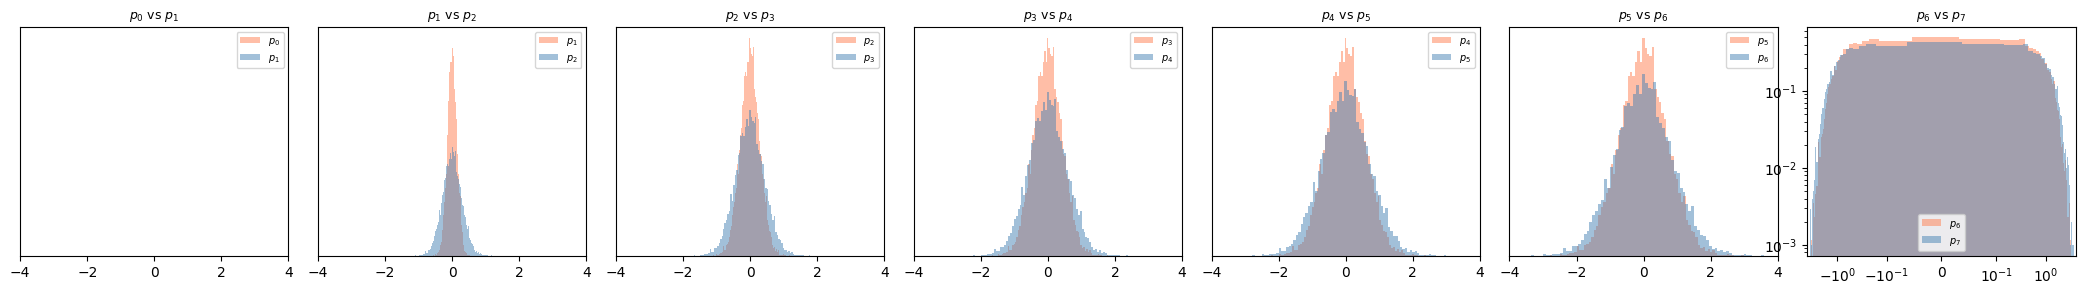

In [31]:
fig, axes = plt.subplots(1, 7, figsize=(21, 3))

alphas, waymarks = make_waymarks(8)

for k, ax in enumerate(axes):
    xk  = waymarks[k]
    xk1 = waymarks[k+1]

    ax.hist(xk,  bins=80, density=True, alpha=0.5,
            color="coral", label=f"$p_{k}$")
    ax.hist(xk1, bins=80, density=True, alpha=0.5,
            color="steelblue", label=f"$p_{{{k+1}}}$")

    ax.set_xlim(-4, 4)          # ✅ fixed axis
    ax.set_title(f"$p_{k}$ vs $p_{{{k+1}}}$", fontsize=9)
    ax.legend(fontsize=7)
    ax.set_yticks([])

plt.tight_layout()
ax.set_xscale("symlog", linthresh=0.1)
ax.set_xlim(-4, 4)
plt.yscale("log")   # ok for densities
plt.show()

In [22]:
### Quadratic Model ###
class TREQuadraticBridge:
    def __init__(self, b):
        self.theta = 0.0
        self.b = b

    @property
    def w(self):
        return np.exp(self.theta)

    def log_r(self, x):
        return self.b - self.w * x**2

    def r(self, x):
        return np.exp(self.log_r(x))

### losses ###
def logistic_loss(m, x_p, x_q):
    return (
        np.logaddexp(0.0, -m.log_r(x_p)).mean() +
        np.logaddexp(0.0,  m.log_r(x_q)).mean()
    )

def bregman_mse_loss(m, x_p, x_q):
    return 0.5*np.mean(m.r(x_q)**2) - np.mean(m.r(x_p))

### math helpers ###
def b_k(p, q):
    return np.log(q.std() / p.std())

def true_theta(p, q):
    s0, s1 = p.std(), q.std()
    return np.log(0.5 * (s0**-2 - s1**-2))

### Single unified 1‑D optimizer (key fix) ###
def fit_ratio_1d(
    p_num, p_den, b,
    loss="logistic",
    n=10_000, seed=0,
    bounds=(-20, 40)
):
    rng = np.random.default_rng(seed)
    x_p = p_num.rvs(n, random_state=rng)
    x_q = p_den.rvs(n, random_state=rng)

    m = TREQuadraticBridge(b)
    L = logistic_loss if loss=="logistic" else bregman_mse_loss

    def obj(theta):
        m.theta = theta
        return L(m, x_p, x_q)

    res = minimize_scalar(obj, bounds=bounds, method="bounded")
    m.theta = res.x

    return m

### Single DRE ###
def single_dre(p0, pm, n=10_000, seed=0):
    m = fit_ratio_1d(p0, pm, b_k(p0, pm), "logistic", n, seed)
    return true_theta(p0, pm), m.theta

### TRE ###
def run_tre(bridge, loss="logistic", n=10_000, seed=0):
    gammas = []
    rows = []

    for k in range(len(bridge)-1):
        p, q = bridge[k], bridge[k+1]
        m = fit_ratio_1d(p, q, b_k(p,q), loss, n, seed+k)
        gammas.append(m.w)
        rows.append((k, true_theta(p,q), m.theta))

    return {
        "theta_true_total": true_theta(bridge[0], bridge[-1]),
        "theta_hat_total": np.log(np.sum(gammas)),
        "per_bridge": rows,
    }


In [28]:
n_runs = 1000
bridge = make_bridge(8)
θ_true = true_theta(bridge[0], bridge[-1])

dre = np.array([single_dre(bridge[0], bridge[-1], seed=i)[1] for i in range(n_runs)])
log = np.array([run_tre(bridge, "logistic", seed=i)["theta_hat_total"] for i in range(n_runs)])
bre = np.array([run_tre(bridge, "bregman",  seed=i)["theta_hat_total"] for i in range(n_runs)])

print(f"Single DRE:   θ_true={θ_true:.6f}, θ̂={dre.mean():.6f} ± {dre.std():.6f}")
print(f"Logistic TRE: θ_true={θ_true:.6f}, θ̂={log.mean():.6f} ± {log.std():.6f}")
print(f"Bregman TRE:  θ_true={θ_true:.6f}, θ̂={bre.mean():.6f} ± {bre.std():.6f}")

Single DRE:   θ_true=26.937874, θ̂=22.362925 ± 2.244978
Logistic TRE: θ_true=26.937874, θ̂=26.938389 ± 0.014648
Bregman TRE:  θ_true=26.937874, θ̂=26.938362 ± 0.030079


### MI

{'Sigma_shape': (6, 6),
 'Sigma': array([[1. , 0.8, 0. , 0. , 0. , 0. ],
        [0.8, 1. , 0. , 0. , 0. , 0. ],
        [0. , 0. , 1. , 0.8, 0. , 0. ],
        [0. , 0. , 0.8, 1. , 0. , 0. ],
        [0. , 0. , 0. , 0. , 1. , 0.8],
        [0. , 0. , 0. , 0. , 0.8, 1. ]]),
 'samples': array([[-1.52450491e-01, -8.61058311e-02, -4.38164743e-01,
         -7.76951801e-01,  1.09792810e-02,  2.39672074e-01],
        [-8.36921659e-01, -1.63724447e+00,  8.64718555e-01,
          4.70525174e-01, -9.11548314e-01, -8.85411469e-01],
        [ 2.43728113e+00,  1.97415459e+00,  1.35408471e+00,
          1.00986510e+00,  3.07586889e-01,  1.07541105e-01],
        [-8.22620705e-01,  4.16066758e-02,  3.32291714e-01,
         -8.84143376e-02, -1.10017227e+00, -8.77857777e-01],
        [-5.65631915e-01, -1.14858223e+00,  8.50090935e-01,
          5.60599705e-01, -1.58819709e-01, -1.95560847e-02],
        [ 7.86777517e-01,  1.12883830e+00,  8.31729328e-02,
          2.18935282e-01,  8.60626564e-02,  3.108

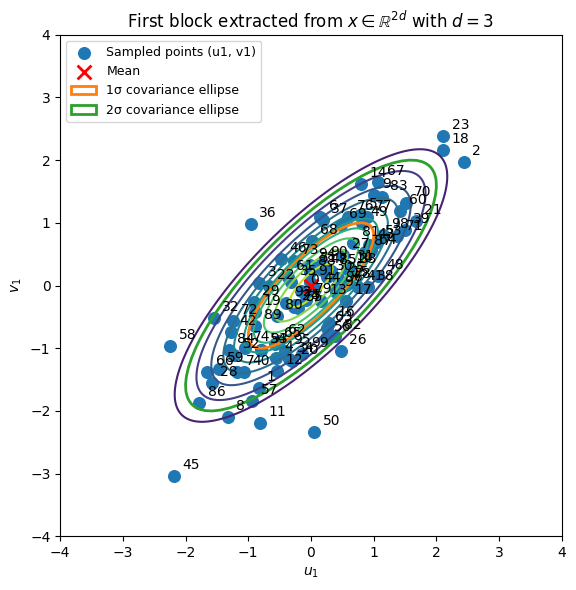

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

# Recreate the helper functions from the earlier code

def make_cov(d, rho=0.8):
    block = np.array([[1.0, rho], [rho, 1.0]])
    return np.kron(np.eye(d), block)


def sample_x(d, n=1, rho=0.8, mean=None, seed=None):
    rng = np.random.default_rng(seed)
    if mean is None:
        mean = np.zeros(2 * d)
    mean = np.asarray(mean, dtype=float)
    Sigma = make_cov(d, rho)
    return rng.multivariate_normal(mean, Sigma, size=n)

# Parameters from the user's example
rho = 0.8
d = 3
Sigma = make_cov(d, rho)
samples = sample_x(d, n=100, seed=0, rho=rho)

# Extract the first correlated pair: (u1, v1) = (x_1, x_2) in 1-based indexing
# In 0-based Python indexing these are columns 0 and 1.
u1 = samples[:, 0]
v1 = samples[:, 1]

# Build the marginal 2D Gaussian for (u1, v1)
mu2 = np.array([0.0, 0.0])
Sigma2 = Sigma[:2, :2]

# Density grid for the marginal
x = np.linspace(-4, 4, 301)
y = np.linspace(-4, 4, 301)
U, V = np.meshgrid(x, y)
UV = np.stack([U, V], axis=-1)
inv_Sigma2 = np.linalg.inv(Sigma2)
det_Sigma2 = np.linalg.det(Sigma2)
const = 1.0 / (2 * np.pi * np.sqrt(det_Sigma2))
D = UV - mu2
quad = np.einsum('...i,ij,...j->...', D, inv_Sigma2, D)
Z = const * np.exp(-0.5 * quad)

# Eigen-decomposition for covariance ellipse
vals, vecs = np.linalg.eigh(Sigma2)
order = vals.argsort()[::-1]
vals = vals[order]
vecs = vecs[:, order]
angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))

fig, ax = plt.subplots(figsize=(7, 6))
ax.contour(U, V, Z, levels=10)
ax.scatter(u1, v1, s=70, color='tab:blue', label='Sampled points (u1, v1)')

# Annotate sample indices
for i, (a, b) in enumerate(zip(u1, v1)):
    ax.annotate(str(i), (a, b), textcoords='offset points', xytext=(6, 5), fontsize=10)

# Mean and covariance ellipses
ax.scatter([0], [0], color='red', marker='x', s=100, linewidths=2, label='Mean')
for nsig, color in [(1, 'tab:orange'), (2, 'tab:green')]:
    ell = Ellipse(
        xy=(0, 0),
        width=2 * nsig * np.sqrt(vals[0]),
        height=2 * nsig * np.sqrt(vals[1]),
        angle=angle,
        edgecolor=color,
        facecolor='none',
        lw=2,
        label=f'{nsig}σ covariance ellipse'
    )
    ax.add_patch(ell)

ax.set_xlabel(r'$u_1$')
ax.set_ylabel(r'$v_1$')
ax.set_title(r'First block extracted from $x \in \mathbb{R}^{2d}$ with $d=3$')
ax.set_aspect('equal', adjustable='box')
ax.legend(loc='upper left', fontsize=9)

# Add a text box showing the exact extracted points and the first 2x2 block
# points_text = '\n'.join([f'{i}: ({u1[i]: .3f}, {v1[i]: .3f})' for i in range(len(u1))])
# matrix_text = 'Sigma[0:2,0:2] = [[1, 0.8], [0.8, 1]]'
# ax.text(-3.95, -3.85, matrix_text + '\n\nSample points:\n' + points_text,
#         fontsize=9, bbox=dict(facecolor='white', alpha=0.9, edgecolor='0.7'))

fig.tight_layout()

# Also save the numeric values for easy reporting
result = {
    'Sigma_shape': Sigma.shape,
    'Sigma': Sigma,
    'samples': samples,
    'u1_v1': np.column_stack([u1, v1]),
    'Sigma2': Sigma2,
    'out': out
}
result

In [17]:
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim


# ============================================================
# 1. Problem setup
# ============================================================

def make_cov(d, rho=0.8):
    """
    Sigma = I_d kron [[1, rho], [rho, 1]]
    Shape: (2d, 2d)
    """
    block = np.array([[1.0, rho],
                      [rho, 1.0]], dtype=np.float64)
    return np.kron(np.eye(d), block)


def sample_p(d, n, rho=0.8, seed=None):
    """
    Sample from p0(x) = N(0, Sigma), where x in R^{2d}.
    """
    rng = np.random.default_rng(seed)
    mean = np.zeros(2 * d, dtype=np.float64)
    cov = make_cov(d, rho)
    x = rng.multivariate_normal(mean, cov, size=n)
    return x.astype(np.float32)


def sample_q(d, n, seed=None):
    """
    Sample from pm(x) = q(x) = N(0, I_{2d}).
    """
    rng = np.random.default_rng(seed)
    x = rng.standard_normal(size=(n, 2 * d))
    return x.astype(np.float32)


def sample_block_p(n, rho=0.8, seed=None):
    """
    Sample one 2D correlated block z=(u,v) from N(0, [[1,rho],[rho,1]]).
    """
    rng = np.random.default_rng(seed)
    mean = np.zeros(2, dtype=np.float64)
    cov = np.array([[1.0, rho],
                    [rho, 1.0]], dtype=np.float64)
    z = rng.multivariate_normal(mean, cov, size=n)
    return z.astype(np.float32)


def sample_block_q(n, seed=None):
    """
    Sample one 2D standard normal block z from N(0, I_2).
    """
    rng = np.random.default_rng(seed)
    z = rng.standard_normal(size=(n, 2))
    return z.astype(np.float32)


def true_mi(num_dims, rho=0.8):
    """
    num_dims = 2d
    MI = -(d/2) log(1-rho^2) = -(num_dims/4) log(1-rho^2)
    """
    d = num_dims // 2
    return -0.5 * d * math.log(1.0 - rho ** 2)


# ============================================================
# 2. Analytic bridge parameters from the derivation
# ============================================================

def analytic_block_W_b(rho=0.8):
    """
    From the derivation:

      log r_k(z) = z^T W z + b,
      W = 1/(2(1-rho^2)) * [[-rho^2, rho],
                            [ rho,   -rho^2]]
      b = -1/2 log(1-rho^2)
    """
    denom = 2.0 * (1.0 - rho ** 2)
    W = np.array([[-rho ** 2 / denom,  rho / denom],
                  [ rho / denom,       -rho ** 2 / denom]], dtype=np.float64)
    b = -0.5 * math.log(1.0 - rho ** 2)
    return W, b


def exact_tre_log_ratio(x, rho=0.8):
    """
    Exact TRE log-ratio using the analytic per-block bridge.
    x shape: (n, 2d)
    Returns shape: (n,)
    """
    W, b = analytic_block_W_b(rho)
    x = np.asarray(x, dtype=np.float64)
    n, D = x.shape
    d = D // 2
    z = x.reshape(n, d, 2)  # blocks
    quad = np.einsum("ndi,ij,ndj->nd", z, W, z) + b
    return quad.sum(axis=1)


# ============================================================
# 3. Quadratic bridge model: s(x) = x^T W x + b
# ============================================================

class QuadraticBridge(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.A = nn.Parameter(torch.zeros(dim, dim))
        self.b = nn.Parameter(torch.zeros(1))

    def symmetric_W(self):
        return 0.5 * (self.A + self.A.T)

    def forward(self, x):
        """
        x shape: (batch, dim)
        returns score shape: (batch,)
        """
        W = self.symmetric_W()
        quad = torch.sum((x @ W) * x, dim=1)
        return quad + self.b


# ============================================================
# 4. Ratio-estimation training
# ============================================================

def fit_quadratic_ratio_model(
    x_p,
    x_q,
    dim,
    lr=1e-2,
    weight_decay=1e-4,
    steps=1000,
    batch_size=256,
    device="cpu",
    verbose=False,
):
    """
    Train s_theta(x) = x^T W x + b as a discriminative ratio model.

    We use equal class priors and optimize logistic regression:
        label 1 for p samples
        label 0 for q samples

    At optimum:
        s_theta(x) ~= log p(x)/q(x)
    """
    model = QuadraticBridge(dim).to(device)

    x_p_t = torch.tensor(x_p, dtype=torch.float32, device=device)
    x_q_t = torch.tensor(x_q, dtype=torch.float32, device=device)

    y_p = torch.ones(len(x_p_t), dtype=torch.float32, device=device)
    y_q = torch.zeros(len(x_q_t), dtype=torch.float32, device=device)

    X = torch.cat([x_p_t, x_q_t], dim=0)
    y = torch.cat([y_p, y_q], dim=0)

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.BCEWithLogitsLoss()

    n = X.shape[0]

    for step in range(steps):
        idx = torch.randint(0, n, (batch_size,), device=device)
        xb = X[idx]
        yb = y[idx]

        logits = model(xb)
        loss = criterion(logits, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if verbose and ((step + 1) % 200 == 0 or step == 0):
            print(f"step {step+1:4d} | loss {loss.item():.6f}")

    return model


@torch.no_grad()
def estimate_mi_from_model(model, x_p, device="cpu"):
    """
    MI estimate = E_{p}[ log p(x)/q(x) ] ~= average model score on p-samples.
    """
    x_p_t = torch.tensor(x_p, dtype=torch.float32, device=device)
    scores = model(x_p_t).cpu().numpy()
    return float(scores.mean())


# ============================================================
# 5. TRE estimator
# ============================================================

def estimate_mi_tre_learned(
    num_dims,
    rho=0.8,
    n_train=4000,
    n_eval=10000,
    seed=0,
    lr=1e-2,
    weight_decay=1e-4,
    steps=600,
    batch_size=256,
    device="cpu",
):
    """
    Learn a single 2D bridge on one block z=(u,v), then sum across d blocks.

    Because all blocks are identical, we can fit one 2D bridge and reuse it
    on every block.
    """
    d = num_dims // 2

    # Train on 2D block samples
    z_p = sample_block_p(n_train, rho=rho, seed=seed)
    z_q = sample_block_q(n_train, seed=seed + 12345)

    block_model = fit_quadratic_ratio_model(
        z_p, z_q,
        dim=2,
        lr=lr,
        weight_decay=weight_decay,
        steps=steps,
        batch_size=batch_size,
        device=device,
    )

    # Evaluate on full p-samples
    x_eval = sample_p(d, n_eval, rho=rho, seed=seed + 999)
    x_eval_t = torch.tensor(x_eval, dtype=torch.float32, device=device).reshape(n_eval, d, 2)

    scores = []
    for k in range(d):
        z_k = x_eval_t[:, k, :]
        scores.append(block_model(z_k))

    total_score = torch.stack(scores, dim=0).sum(dim=0)
    return float(total_score.mean().cpu().numpy())


def estimate_mi_tre_analytic(
    num_dims,
    rho=0.8,
    n_eval=10000,
    seed=0,
):
    """
    Use the exact analytic W,b for each 2D block and sum them.
    This should be extremely close to ground truth (up to MC error).
    """
    d = num_dims // 2
    x_eval = sample_p(d, n_eval, rho=rho, seed=seed)
    log_ratio = exact_tre_log_ratio(x_eval, rho=rho)
    return float(log_ratio.mean())


# ============================================================
# 6. Single-ratio estimator
# ============================================================

def estimate_mi_single_ratio(
    num_dims,
    rho=0.8,
    n_train=4000,
    n_eval=10000,
    seed=0,
    lr=3e-3,
    weight_decay=1e-4,
    steps=1200,
    batch_size=256,
    device="cpu",
):
    """
    Fit one quadratic bridge directly in R^{2d}:
        s(x) = x^T W x + b
    and estimate MI as E_p[s(x)].
    """
    d = num_dims // 2
    x_p = sample_p(d, n_train, rho=rho, seed=seed)
    x_q = sample_q(d, n_train, seed=seed + 12345)

    model = fit_quadratic_ratio_model(
        x_p, x_q,
        dim=num_dims,
        lr=lr,
        weight_decay=weight_decay,
        steps=steps,
        batch_size=batch_size,
        device=device,
    )

    x_eval = sample_p(d, n_eval, rho=rho, seed=seed + 999)
    return estimate_mi_from_model(model, x_eval, device=device)


# ============================================================
# 7. Run experiment across dimensions and seeds
# ============================================================

def run_experiment(
    dims=(40, 80, 160, 320),
    rho=0.8,
    seeds=(0, 1, 2, 3, 4),
    n_train=4000,
    n_eval=10000,
    device=None,
    use_analytic_tre=False,
):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    results = {
        "dims": [],
        "ground_truth": [],
        "tre_mean": [],
        "tre_std": [],
        "single_mean": [],
        "single_std": [],
    }

    for D in dims:
        print(f"\n=== dimension {D} ===")
        gt = true_mi(D, rho=rho)

        tre_vals = []
        single_vals = []

        for seed in seeds:
            if use_analytic_tre:
                tre_hat = estimate_mi_tre_analytic(
                    num_dims=D,
                    rho=rho,
                    n_eval=n_eval,
                    seed=seed,
                )
            else:
                tre_hat = estimate_mi_tre_learned(
                    num_dims=D,
                    rho=rho,
                    n_train=n_train,
                    n_eval=n_eval,
                    seed=seed,
                    lr=1e-2,
                    weight_decay=1e-4,
                    steps=600,
                    batch_size=256,
                    device=device,
                )

            single_hat = estimate_mi_single_ratio(
                num_dims=D,
                rho=rho,
                n_train=n_train,
                n_eval=n_eval,
                seed=seed,
                lr=3e-3,
                weight_decay=1e-4,
                steps=1200,
                batch_size=256,
                device=device,
            )

            tre_vals.append(tre_hat)
            single_vals.append(single_hat)

            print(
                f"seed {seed:2d} | "
                f"gt={gt:7.3f} | "
                f"TRE={tre_hat:7.3f} | "
                f"single={single_hat:7.3f}"
            )

        results["dims"].append(D)
        results["ground_truth"].append(gt)
        results["tre_mean"].append(np.mean(tre_vals))
        results["tre_std"].append(np.std(tre_vals, ddof=1))
        results["single_mean"].append(np.mean(single_vals))
        results["single_std"].append(np.std(single_vals, ddof=1))

    return results


# ============================================================
# 8. Plot results
# ============================================================

def plot_results(results, title=None):
    dims = np.array(results["dims"])
    gt = np.array(results["ground_truth"])
    tre_mean = np.array(results["tre_mean"])
    tre_std = np.array(results["tre_std"])
    single_mean = np.array(results["single_mean"])
    single_std = np.array(results["single_std"])

    plt.figure(figsize=(8, 6))

    plt.plot(dims, tre_mean, "-o", color="red", label="TRE")
    plt.fill_between(dims, tre_mean - tre_std, tre_mean + tre_std,
                     color="red", alpha=0.15)

    plt.plot(dims, single_mean, "-o", color="blue", label="single ratio")
    plt.fill_between(dims, single_mean - single_std, single_mean + single_std,
                     color="blue", alpha=0.15)

    plt.plot(dims, gt, "-o", color="black", label="ground truth")

    plt.xlabel("number of dimensions")
    plt.ylabel("estimated mutual information")
    if title is not None:
        plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
# ============================================================
# 9. Main
# ============================================================

if __name__ == "__main__":
    torch.manual_seed(0)
    np.random.seed(0)

    results = run_experiment(
        dims=(40, 80, 160, 320),
        rho=0.8,
        seeds=(0, 1, 2, 3, 4),
        n_train=4000,
        n_eval=10000,
        use_analytic_tre=False,  # set True for exact TRE sanity-check
    )

    plot_results(
        results,
        title="High-dimensional Gaussian: TRE vs single-ratio MI estimation"
    )

    print("\nSummary:")
    for D, gt, tre, single in zip(
        results["dims"],
        results["ground_truth"],
        results["tre_mean"],
        results["single_mean"],
    ):
        print(
            f"D={D:3d} | ground truth={gt:8.3f} | "
            f"TRE={tre:8.3f} | single ratio={single:8.3f}"
        )